In [1]:
config_path = "configs/distFlow33_config.yaml" 
dim_state = 32
out_dir = "figures_static"

In [2]:
import numpy as np
import cvxpy as cp
from configs.config_loader import ConfigLoader
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import MultipleLocator
from pfmodels import PFModel, LinDistFlow, DistFlow
from src.utils.case_loader import load_case_from_files
from src.controllers.voltvar_controllers import DistributedVoltVarController
from src.analysis.plot_tools import save_results
from pathlib import Path
import json
import datetime
import pickle
import warnings
from typing import Optional, List, Dict, Any, Tuple, Union, Type
from plot_util import compute_ylim,plot_pts_for_seed,tail_mean_1traj,pct_lower
from utilfuncs import has_nan, get_v_ctrl_from_sol,func_grad_u, func_cost1, load_kvec_from_pckl_simple,extract_v_ctrl,tail_mean,head_mean,tail_mean_last_k,head_mean_first_k
from convrelax import VoltVarController, CentralizedVoltVarController
from dataloaders import prepare_inputs_with_measurements
np.random.seed(1)


## config

In [3]:
config_path = "distFlow33_config.yaml"
config_loader = ConfigLoader(config_path)
model_config = config_loader.get_model_config()
load_dir = './src/cases/pypower'
pf_model_type = model_config['pf_model']
case_name = model_config['case']
my_case = load_case_from_files(load_dir,case_name)
pf_model = DistFlow(my_case)
n_bus = pf_model.n_bus
p = -my_case['bus'][1:,2].reshape(-1,1)/my_case['baseMVA']+0.001*np.random.uniform(low=0.5, high=1.0, size=(32,1))
q = -my_case['bus'][1:,3].reshape(-1,1)/my_case['baseMVA']
dis_vv_controllers = DistributedVoltVarController(config_loader)
controlled_nodes = dis_vv_controllers.nodes
sol = pf_model.runpf(p,q)
new_p = p
sol_list = []
sol_list.append(sol)
for t in range(1):
    v_list = sol_list[-1]['v']
    v_dict = {node:v_list[node] for node in controlled_nodes}
    q_commend = dis_vv_controllers.get_q(v_dict)
    new_q = q
    new_p = new_p+np.clip(np.random.randn(n_bus-1,1)*(10**(-4)),-8*10**(-5),8*10**(-5))
    for node, q_injection in q_commend.items():
        new_q[node] += q_injection
    sol = pf_model.runpf(new_p,new_q)
    sol_list.append(sol)
q_init = new_q.copy()
p_init = new_p.copy()

## Env setup

In [4]:
dim_action = np.size(controlled_nodes)
dim_state = n_bus
dim_obs = dim_action
PredictLength = 20
sigma_e = 0.01
SimulationLength=dim_state+PredictLength*(dim_action+1)-1+1000
List_noise = 0.1*np.random.normal(np.zeros((dim_action, SimulationLength+100)), sigma_e)
List_noise_state = 0.2*np.clip(np.random.randn(n_bus-1,SimulationLength+100)*(10**(-4)),-8*10**(-5),8*10**(-5))
s_ref = np.ones((1, dim_action))
C_ACTION = 0.1
R_U = None
Q_ABS_MAX = 0.05
Sens_length = 100
Opt_length = 20
T = Sens_length + Opt_length
s_ref_ctrl = np.asarray(s_ref, dtype=float).reshape(-1)

# Linear Control

In [5]:
controlled_nodes = np.asarray(controlled_nodes, dtype=int).ravel()
m = controlled_nodes.size
k_file = "src/cases/pypower/case33/linear_k.pckl"
K_vec = load_kvec_from_pckl_simple(k_file, controlled_nodes)
K = np.diag(K_vec)

sol_list = []
record_cost_lin = []
Record_u_Linear_lin = []
Trajectory_Linear_lin = []

p_init = np.asarray(p_init, float).reshape(-1, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)
new_p  = p_init.copy()
new_q  = q_init.copy()

for t in range(Sens_length):
    new_p = p_init

    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
    new_q[controlled_nodes] = q_init[controlled_nodes] + nu

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_lin.append(q_ctrl.ravel().copy())
    Trajectory_Linear_lin.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_lin.append(float(c))

v_ref_vec = s_ref.reshape(1, -1)

for t in range(Sens_length, T):
    new_p = p_init

    sol_last = sol_list[-1]
    v_ctrl_last = get_v_ctrl_from_sol(sol_last, controlled_nodes)

    dv = (v_ctrl_last - v_ref_vec).reshape(-1, 1)


    q_next = - (K @ dv)
    q_next = np.clip(q_next, -Q_ABS_MAX, Q_ABS_MAX)

    new_q[controlled_nodes] = q_next

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    if has_nan(v_ctrl):
        print('[Linear-Static] v nan, break at t=', t)
        break

    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_lin.append(q_ctrl.ravel().copy())
    Trajectory_Linear_lin.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_lin.append(float(c))

linear_logs = {
    "sol_list": sol_list,
    "record_cost_linear": record_cost_lin,
    "record_cost_linear_opt": record_cost_lin[Sens_length:],
    "Record_u_Linear_linear": Record_u_Linear_lin,
    "Trajectory_Linear_linear": Trajectory_Linear_lin,
}


In [6]:
def add_zoom_inset_auto(
    ax, x, Y, x_zoom=(20, 30), size=0.38,
    loc_candidates=("upper right", "upper left", "lower left", "lower right"),
    *, inset_ticklabelsize: int = 15,
    inset_ylim=None,
):
    x = np.asarray(x); Y = np.asarray(Y)
    y_rep = np.median(Y, axis=1) if Y.ndim == 2 else Y

    ax.figure.canvas.draw()
    xL, xR = ax.get_xlim(); yB, yT = ax.get_ylim()
    xW, yH = (xR - xL), (yT - yB); box_w, box_h = xW * size, yH * size
    candidates = {
        "upper right":  ((xR - box_w, xR), (yT - box_h, yT)),
        "upper left":   ((xL, xL + box_w), (yT - box_h, yT)),
        "lower left":   ((xL, xL + box_w), (yB, yB + box_h)),
        "lower right":  ((xR - box_w, xR), (yB, yB + box_h)),
    }
    best_loc, best_score = None, None
    for loc in loc_candidates:
        (cx0, cx1), (cy0, cy1) = candidates[loc]
        mask = (x >= cx0) & (x <= cx1) & (y_rep >= cy0) & (y_rep <= cy1)
        score = int(np.count_nonzero(mask))
        if best_score is None or score < best_score:
            best_score, best_loc = score, loc

    iax = inset_axes(
        ax,
        width=f"{int(size*100)}%",
        height=f"{int(size*100)}%",
        loc=best_loc,
        borderpad=1.0
    )

    if Y.ndim == 2:
        iax.plot(x, Y, lw=1.2)
    else:
        iax.plot(x, Y, lw=1.6)

    x0, x1 = x_zoom
    iax.set_xlim(x0, x1)
    iax.xaxis.set_major_locator(MultipleLocator(5))

    if inset_ylim is not None:
        iax.set_ylim(inset_ylim[0], inset_ylim[1])
    else:
        zmask = (x >= x0) & (x <= x1)
        if np.any(zmask):
            if Y.ndim == 2:
                y_min = float(np.min(Y[zmask, :])); y_max = float(np.max(Y[zmask, :]))
            else:
                y_min = float(np.min(Y[zmask]));    y_max = float(np.max(Y[zmask]))
            pad = 0.08 * (y_max - y_min + 1e-12)
            iax.set_ylim(y_min - pad, y_max + pad)

    iax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    iax.tick_params(axis="both", labelsize=inset_ticklabelsize)


    from matplotlib.ticker import ScalarFormatter
    yfmt = ScalarFormatter(useMathText=True)
    yfmt.set_scientific(True)
    yfmt.set_powerlimits((-3, 3))
    yfmt.set_useOffset(False)
    iax.yaxis.set_major_formatter(yfmt)

    offset_text = iax.yaxis.get_offset_text()
    offset_text.set_fontsize(inset_ticklabelsize)

    try:
        ax.indicate_inset_zoom(iax, edgecolor='0.25', alpha=0.9)
    except Exception:
        pass

    return iax, best_loc

Linear Control


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/2049219101.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(selected_cols))


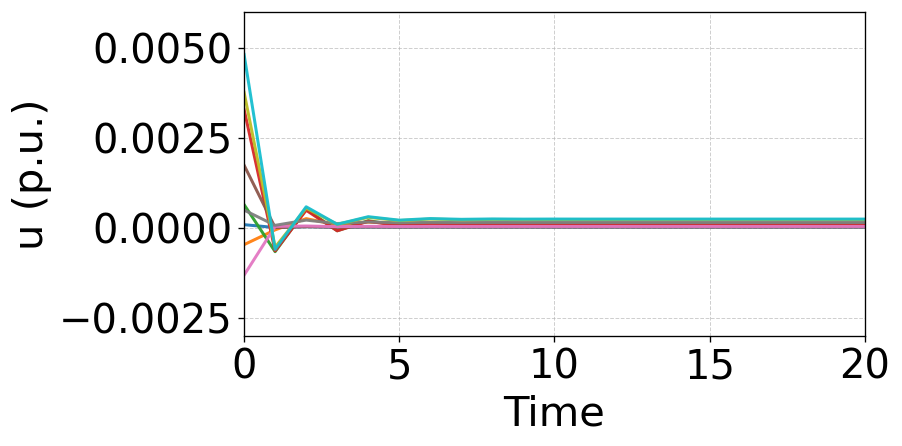

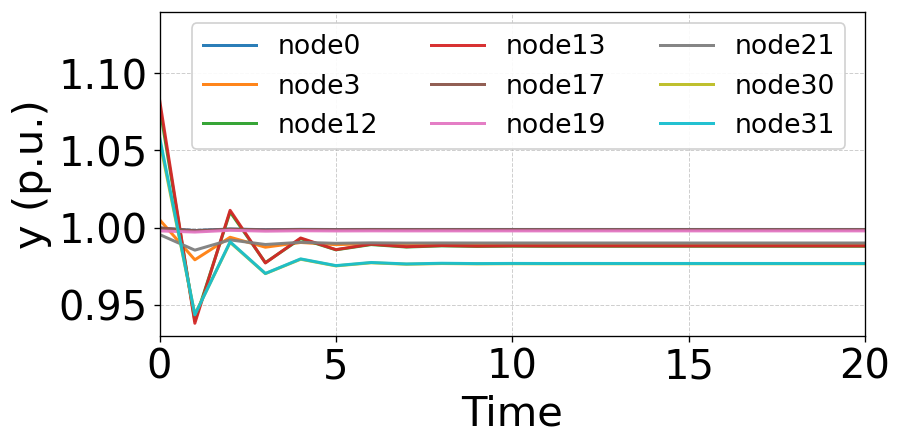

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/2049219101.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


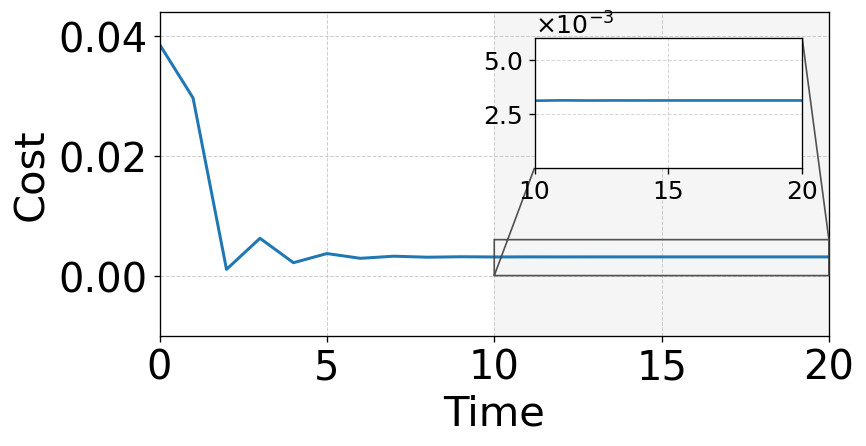

Saved to:
 - figures_static/LIN_actions-static_9nodes.pdf
 - figures_static/LIN_voltages-static_9nodes.pdf
 - figures_static/LIN_cost-static.pdf


In [7]:
print("Linear Control")

MANUAL_Y = {
    "action":  (-0.003, 0.006),
    "voltage": (0.93, 1.140),
    "cost":   (-0.01, 0.044),
}
FORCE_SYMM = {
    "action":  False,
    "voltage": False,
    "cost":    False,
}

Trajectory_Linear_lin = np.squeeze(np.asarray(Trajectory_Linear_lin))
Record_u_Linear_lin   = np.squeeze(np.asarray(Record_u_Linear_lin))
record_cost_lin       = np.asarray(record_cost_lin).ravel()

N_total = Record_u_Linear_lin.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost    = max(0, Sens_length - 1)
idx_cost      = slice(start_cost, N_total)
time_seg_cost = np.arange(0, Opt_length_pretty + 1)

zoom_range = (10, 20)
os.makedirs(out_dir, exist_ok=True)
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

Y_action  = Record_u_Linear_lin[idx_opt, :]
Y_voltage = Trajectory_Linear_lin[idx_opt, :]
Y_cost    = record_cost_lin[idx_cost]

ylim_action  = compute_ylim(
    [Y_action], MANUAL_Y["action"],
    pad_frac=0.06, symmetric=FORCE_SYMM["action"]
)
ylim_voltage = compute_ylim(
    [Y_voltage], MANUAL_Y["voltage"],
    pad_frac=0.03, symmetric=FORCE_SYMM["voltage"]
)
ylim_cost    = compute_ylim(
    [Y_cost], MANUAL_Y["cost"],
    pad_frac=0.08, symmetric=FORCE_SYMM["cost"]
)

xticks_main = np.arange(0, Opt_length_pretty + 1, 5)
T_opt, n_ctrl = Y_voltage.shape
opt_step_for_selection = 5
if opt_step_for_selection >= T_opt:
    opt_step_for_selection = T_opt - 1

v_at_step = np.asarray(
    Y_voltage[opt_step_for_selection, :], float
).ravel()
sorted_idx = np.argsort(v_at_step)
num_must = min(2, n_ctrl)
smallest = sorted_idx[:num_must]
largest  = sorted_idx[-num_must:]
mandatory = np.unique(np.concatenate([smallest, largest]))
target_num = min(9, n_ctrl)

remaining_needed = target_num - len(mandatory)
all_idx = np.arange(n_ctrl, dtype=int)
rest_candidates = np.setdiff1d(
    all_idx, mandatory, assume_unique=True
)

if remaining_needed > 0 and rest_candidates.size > 0:
    rng = np.random.default_rng(42)
    extra = rng.choice(
        rest_candidates,
        size=min(remaining_needed, rest_candidates.size),
        replace=False,
    )
    selected_cols = np.concatenate([mandatory, extra])
else:
    selected_cols = mandatory.copy()

selected_cols = np.sort(selected_cols)

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    node_ids_for_plot = np.asarray(
        controlled_nodes, dtype=int
    )[selected_cols]
else:
    node_ids_for_plot = selected_cols

sel_path = os.path.join(out_dir, "plotted_nodes.npy")
np.save(sel_path, node_ids_for_plot)

Y_action_sel = Y_action[:, selected_cols]
fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)

cmap = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}",
    )

ax.set_xlabel("Time")
ax.set_ylabel("u (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)
plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "LIN_actions-static_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

Y_voltage_sel = Y_voltage[:, selected_cols]
fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}",
    )

ax.set_xlabel("Time")
ax.set_ylabel("y (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

vmin, vmax = ax.get_ylim()
vstep = 0.05
vstart = np.ceil(vmin / vstep) * vstep
vy = np.arange(vstart, vmax + 1e-12, vstep)
ax.set_yticks(np.round(vy, 3))

leg = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=16,
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "LIN_voltages-static_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)

x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color="grey", alpha=0.08, linewidth=0)

add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(1e-5, 0.6e-2),
)
plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "LIN_cost-static.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")


# Convex Relaxation

In [8]:
cvc = CentralizedVoltVarController(model=pf_model, configLoader=config_loader)
controlled_nodes = np.asarray(cvc.nodes, dtype=int).ravel()
s_ref = np.asarray(s_ref, dtype=float).ravel()
if s_ref.size == len(controlled_nodes):
    s_ref_ctrl = s_ref.reshape(1, -1)
else:
    if cvc.index_mode == "reduced":
        idx_full = [k + 1 for k in controlled_nodes]
    else:
        idx_full = controlled_nodes
    s_ref_ctrl = s_ref[np.array(idx_full, dtype=int)].reshape(1, -1)

p0 = np.asarray(p_init, dtype=float).reshape(-1, 1)
q0 = np.asarray(q_init, dtype=float).reshape(-1, 1)
sol_list = []
record_cost_cvc        = []
Record_q_total_cvc     = []
Record_u_Linear_cvc    = []
Trajectory_Linear_cvc  = []
new_p = p0.copy()
new_q = q0.copy()

for t in range(Sens_length):
    new_p = p0
    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
    idx_ctrl = controlled_nodes
    new_q[idx_ctrl, 0] = q0[idx_ctrl, 0] + nu.ravel()
    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)
    v_ctrl = extract_v_ctrl(sol, controlled_nodes, cvc)
    q_ctrl_total = new_q[idx_ctrl, 0].reshape(-1, 1)
    u_ctrl       = q_ctrl_total.copy()
    Trajectory_Linear_cvc.append(v_ctrl)
    Record_q_total_cvc.append(q_ctrl_total.ravel())
    Record_u_Linear_cvc.append(u_ctrl.ravel())

    c = func_cost1(
        v_ctrl,
        s_ref_ctrl,
        q_ctrl_total,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_cvc.append(float(c))

for t in range(Sens_length, T):
    v_prev = sol_list[-1]['v']
    v_prev_all = np.asarray(v_prev, dtype=float).ravel()

    if cvc.index_mode == "reduced":
        idx_full = np.asarray(controlled_nodes, dtype=int) + 1
    else:
        idx_full = np.asarray(controlled_nodes, dtype=int)
    v_ctrl_prev = v_prev_all[idx_full]
    v_dict = {int(k): float(v) for k, v in zip(controlled_nodes, v_ctrl_prev)}

    q_total_dict = cvc.get_q(
        v_dict=v_dict,
        p=new_p.squeeze(),
        q=new_q.squeeze(),
        s_ref=s_ref_ctrl,
        c_action=C_ACTION,
        R_u=R_U,
        q_abs_max=Q_ABS_MAX,
        return_absolute=True,
        solver=None,
        verbose=False
    )

    q_total_t = new_q.copy()
    idx_ctrl = np.asarray(controlled_nodes, dtype=int)
    for k, q_abs in q_total_dict.items():
        q_total_t[int(k), 0] = float(q_abs)

    sol = pf_model.runpf(new_p, q_total_t)
    sol_list.append(sol)

    v_ctrl = extract_v_ctrl(sol, controlled_nodes, cvc)

    q_ctrl_total = q_total_t[idx_ctrl, 0].reshape(-1, 1)
    u_ctrl       = (q_total_t - new_q)[idx_ctrl, 0].reshape(-1, 1)

    Trajectory_Linear_cvc.append(v_ctrl)
    Record_q_total_cvc.append(q_ctrl_total.ravel())
    Record_u_Linear_cvc.append(u_ctrl.ravel())

    c = func_cost1(
        v_ctrl,
        s_ref_ctrl,
        q_ctrl_total,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_cvc.append(float(c))

    new_q = q_total_t.copy()

record_cost_centralized       = record_cost_cvc
Record_q_total_centralized    = Record_q_total_cvc
Record_u_Linear_centralized   = Record_u_Linear_cvc
Trajectory_Linear_centralized = Trajectory_Linear_cvc


/opt/anaconda3/lib/python3.13/site-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)


Convex Relaxation


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/133201437.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(selected_cols))


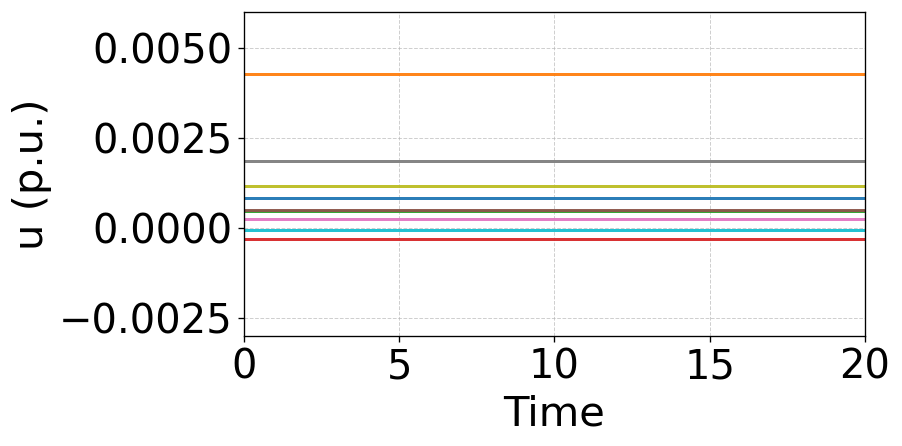

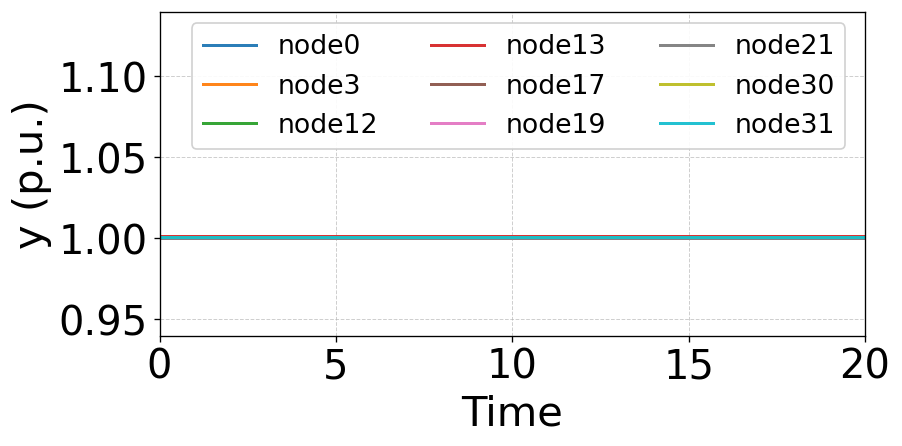

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/133201437.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


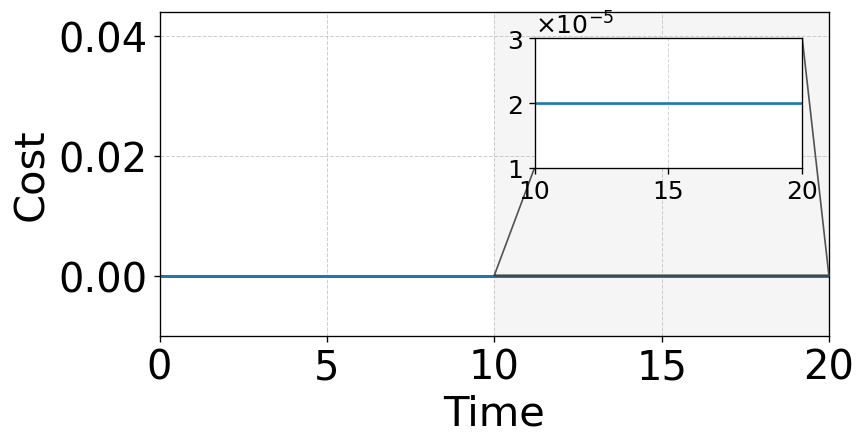

Saved to:
 - figures_static/CVC_actions-static_9nodes.pdf
 - figures_static/CVC_voltages-static_9nodes.pdf
 - figures_static/CVC_cost-static.pdf


In [9]:
print('Convex Relaxation')
MANUAL_Y = {
    "action":  (-0.003, 0.006),
    "voltage": (0.94, 1.140),
    "cost":   (-0.01, 0.044),
}
FORCE_SYMM = {
    "action":  False,
    "voltage": False,
    "cost":    False,
}
Trajectory_Linear_cvc = np.squeeze(np.asarray(Trajectory_Linear_cvc))
Record_q_total_cvc    = np.squeeze(np.asarray(Record_q_total_cvc))
record_cost_cvc       = np.asarray(record_cost_cvc).ravel()

N_total = Record_q_total_cvc.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost     = max(0, Sens_length - 1)
idx_cost       = slice(start_cost, N_total)
time_seg_cost  = np.arange(0, Opt_length_pretty + 1)

zoom_range = (10, 20)

os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

Y_action_raw  = Record_q_total_cvc[idx_opt, :]
Y_voltage_raw = Trajectory_Linear_cvc[idx_opt, :]
Y_cost_raw    = record_cost_cvc[idx_cost]

Y_action  = Y_action_raw.copy()
Y_voltage = Y_voltage_raw.copy()
Y_cost    = Y_cost_raw.copy()

if Y_action.shape[0] >= 2:
    Y_action[0, :]  = Y_action[1, :]
    Y_voltage[0, :] = Y_voltage[1, :]
    Y_cost[0]       = Y_cost[1]

ylim_action  = compute_ylim([Y_action],  MANUAL_Y["action"],  pad_frac=0.06, symmetric=FORCE_SYMM["action"])
ylim_voltage = compute_ylim([Y_voltage], MANUAL_Y["voltage"], pad_frac=0.03, symmetric=FORCE_SYMM["voltage"])
ylim_cost    = compute_ylim([Y_cost],    MANUAL_Y["cost"],    pad_frac=0.08, symmetric=FORCE_SYMM["cost"])


xticks_main = np.arange(0, Opt_length_pretty + 1, 5)

sel_path = os.path.join(out_dir, "plotted_nodes.npy")
selected_node_ids = np.load(sel_path)
T_opt, n_ctrl = Y_voltage.shape

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    controlled_nodes_arr = np.asarray(controlled_nodes, dtype=int)
    selected_cols = []
    for nid in selected_node_ids:
        matches = np.where(controlled_nodes_arr == nid)[0]
        if matches.size == 0:
            raise ValueError(f"Node ID {nid} not found in controlled_nodes for CVC.")
        selected_cols.append(matches[0])
    selected_cols = np.asarray(selected_cols, dtype=int)
    node_ids_for_plot = np.asarray(selected_node_ids, dtype=int)
else:
    selected_cols = np.asarray(selected_node_ids, dtype=int)
    node_ids_for_plot = selected_cols

Y_action_sel = Y_action[:, selected_cols]
fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
cmap = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("u (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)

plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "CVC_actions-static_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

Y_voltage_sel = Y_voltage[:, selected_cols]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)

for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("y (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

leg = ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=16
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "CVC_voltages-static_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)

x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color='grey', alpha=0.08, linewidth=0)

add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(1e-5, 3e-5),
)

plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "CVC_cost-static.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")


# Feedback Optimization

We found that for feedback optimization, large learning rate would yield voltage oscillation. See the example case below. 

In [10]:
print('Feedback Optimization with Large Learning Rate')
dis_vv_controllers = DistributedVoltVarController(config_loader)
controlled_nodes = np.asarray(dis_vv_controllers.nodes, dtype=int).ravel()

sol_list = []
record_cost_gd = []
Record_u_Linear_gd = []
record_grad_v_u = []
record_grad_u = []
Trajectory_Linear_gd = []

lr0 = 1e-3
decay_rate_lr = 0.001

p_init = np.asarray(p_init, float).reshape(-1, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)
new_p  = p_init.copy()
new_q  = q_init.copy()

for t in range(Sens_length):
    new_p = p_init
    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
    new_q[controlled_nodes] = q_init[controlled_nodes] + nu

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_gd.append(q_ctrl.ravel().copy())
    Trajectory_Linear_gd.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_gd.append(float(c))

decay_rate = 0.5
sens_coeff = 1 - np.exp(-decay_rate * np.arange(1, Sens_length))

for t in range(Sens_length, T):
    lr = lr0 * (np.exp(-decay_rate_lr * t))
    new_p = p_init

    U_win = np.asarray(Record_u_Linear_gd[t - Sens_length:t], dtype=float)
    V_win = np.asarray(np.squeeze(np.asarray(Trajectory_Linear_gd))[t - Sens_length:t],
                       dtype=float)

    Diff_u = np.diff(U_win, axis=0)
    Diff_x = np.diff(V_win, axis=0)
    if Diff_u.ndim == 1:
        Diff_u = Diff_u.reshape(-1, 1)
    if Diff_x.ndim == 1:
        Diff_x = Diff_x.reshape(-1, 1)

    W = np.diag(sens_coeff)
    A = W @ Diff_u
    B = W @ Diff_x

    AtA = A.T @ A
    AtB = A.T @ B
    mu_base = 0
    scale = np.trace(AtA) / max(1, AtA.shape[0]) if AtA.size else 1.0
    mu = 0
    S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
    J_v_u_estimate = S_T.T

    sol_curr = sol_list[-1]
    v_curr = get_v_ctrl_from_sol(sol_curr, controlled_nodes)

    grad_u = func_grad_u(
        v_curr,
        s_ref.reshape(1, -1),
        J_v_u_estimate,
        new_q[controlled_nodes],
        c_action=C_ACTION,
        R_u=R_U
    )
    if has_nan(np.asarray(grad_u)):
        print('grad_u nan, break at t=', t)
        break

    q_next = new_q[controlled_nodes] - lr * grad_u.reshape((-1, 1))
    new_q[controlled_nodes] = np.clip(q_next, -Q_ABS_MAX, Q_ABS_MAX)

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    if has_nan(v_ctrl):
        print('v nan, break at t=', t)
        break

    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_gd.append(q_ctrl.ravel().copy())
    Trajectory_Linear_gd.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_gd.append(float(c))


Feedback Optimization with Large Learning Rate


Feedback Optimization with Large Learning Rate


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/2107466333.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(selected_cols))


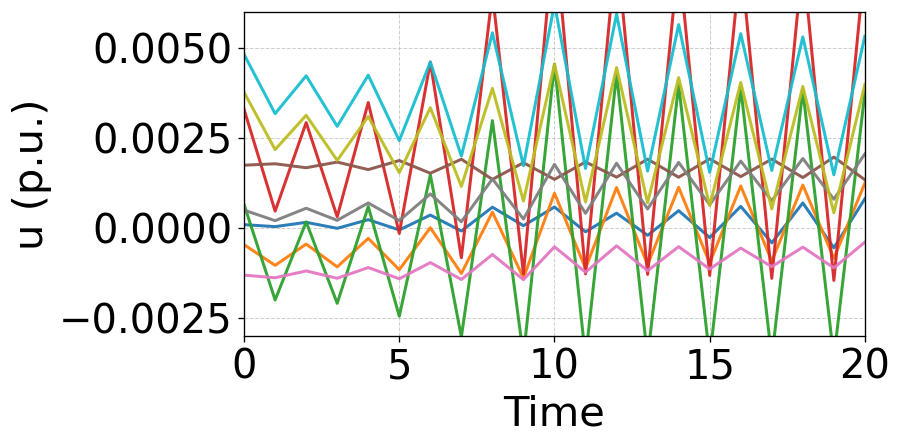

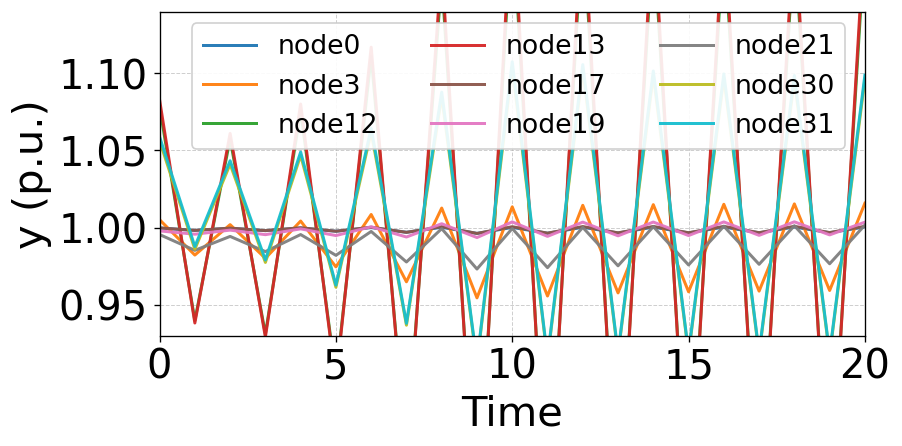

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/2107466333.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


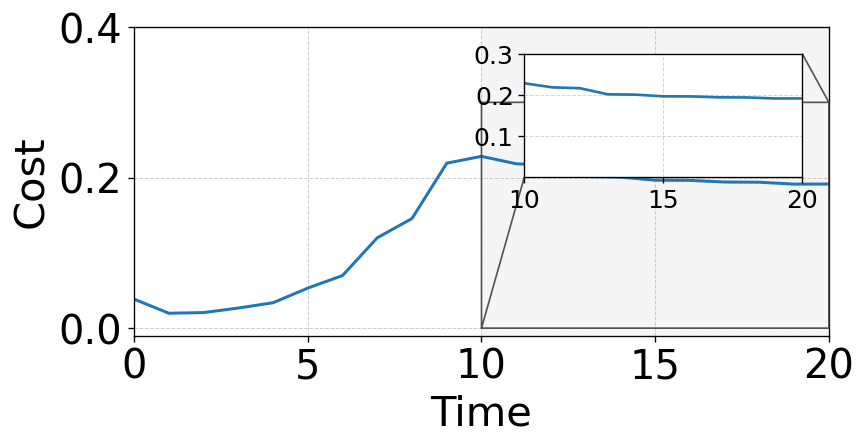

Saved to:
 - figures_static/GD_actions-static_9nodes.pdf
 - figures_static/GD_voltages-static_9nodes.pdf
 - figures_static/GD_cost-static.pdf


In [11]:
print('Feedback Optimization with Large Learning Rate')
MANUAL_Y = {
    "action":  (-0.003, 0.006),
    "voltage": (0.93, 1.140),
    "cost":   (-0.01, 0.4),
}
FORCE_SYMM = {
    "action":  False,
    "voltage": False,
    "cost":    False,
}

Trajectory_Linear_gd = np.squeeze(np.asarray(Trajectory_Linear_gd))
Record_u_Linear_gd   = np.squeeze(np.asarray(Record_u_Linear_gd))
record_cost_gd       = np.asarray(record_cost_gd).ravel()

N_total = Record_u_Linear_gd.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost     = max(0, Sens_length - 1)
idx_cost       = slice(start_cost, N_total)
time_seg_cost  = np.arange(0, Opt_length_pretty + 1)

zoom_range = (10, 20)
os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

Y_action  = Record_u_Linear_gd[idx_opt, :]
Y_voltage = Trajectory_Linear_gd[idx_opt, :]
Y_cost    = record_cost_gd[idx_cost]

ylim_action  = compute_ylim([Y_action],  MANUAL_Y["action"],  pad_frac=0.06, symmetric=FORCE_SYMM["action"])
ylim_voltage = compute_ylim([Y_voltage], MANUAL_Y["voltage"], pad_frac=0.03, symmetric=FORCE_SYMM["voltage"])
ylim_cost    = compute_ylim([Y_cost],    MANUAL_Y["cost"],    pad_frac=0.08, symmetric=FORCE_SYMM["cost"])
xticks_main = np.arange(0, Opt_length_pretty + 1, 5)

sel_path = os.path.join(out_dir, "plotted_nodes.npy")
selected_node_ids = np.load(sel_path)
T_opt, n_ctrl = Y_voltage.shape

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    controlled_nodes_arr = np.asarray(controlled_nodes, dtype=int)
    selected_cols = []
    for nid in selected_node_ids:
        matches = np.where(controlled_nodes_arr == nid)[0]
        if matches.size == 0:
            raise ValueError(f"Node ID {nid} not found in controlled_nodes for GD.")
        selected_cols.append(matches[0])
    selected_cols = np.asarray(selected_cols, dtype=int)
    node_ids_for_plot = np.asarray(selected_node_ids, dtype=int)
else:
    selected_cols = np.asarray(selected_node_ids, dtype=int)
    node_ids_for_plot = selected_cols

Y_action_sel  = Y_action[:, selected_cols]
Y_voltage_sel = Y_voltage[:, selected_cols]

cmap   = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("u (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)


plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "GD_actions-static_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("y (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

vmin, vmax = ax.get_ylim()
vstep = 0.05
vstart = np.ceil(vmin / vstep) * vstep
vy = np.arange(vstart, vmax + 1e-12, vstep)
ax.set_yticks(np.round(vy, 3))

leg = ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=16
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "GD_voltages-static_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)

x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color='grey', alpha=0.08, linewidth=0)
add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(1e-5, 3e-1),
)


plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "GD_cost-static.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")

The following is feedback optimization with a reasonable learning rate.

In [12]:
dis_vv_controllers = DistributedVoltVarController(config_loader)
controlled_nodes = np.asarray(dis_vv_controllers.nodes, dtype=int).ravel()

sol_list = []
record_cost_gd = []
Record_u_Linear_gd = []
record_grad_v_u = []
record_grad_u = []
Trajectory_Linear_gd = []

lr0 = 2e-4
decay_rate_lr = 0.001

p_init = np.asarray(p_init, float).reshape(-1, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)
new_p  = p_init.copy()
new_q  = q_init.copy()

for t in range(Sens_length):
    new_p = p_init
    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
    new_q[controlled_nodes] = q_init[controlled_nodes] + nu

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_gd.append(q_ctrl.ravel().copy())
    Trajectory_Linear_gd.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_gd.append(float(c))

decay_rate = 0.5
sens_coeff = 1 - np.exp(-decay_rate * np.arange(1, Sens_length))

for t in range(Sens_length, T):
    lr = lr0 * (np.exp(-decay_rate_lr * t))
    new_p = p_init

    U_win = np.asarray(Record_u_Linear_gd[t - Sens_length:t], dtype=float)
    V_win = np.asarray(np.squeeze(np.asarray(Trajectory_Linear_gd))[t - Sens_length:t],
                       dtype=float)

    Diff_u = np.diff(U_win, axis=0)
    Diff_x = np.diff(V_win, axis=0)
    if Diff_u.ndim == 1:
        Diff_u = Diff_u.reshape(-1, 1)
    if Diff_x.ndim == 1:
        Diff_x = Diff_x.reshape(-1, 1)

    W = np.diag(sens_coeff)
    A = W @ Diff_u
    B = W @ Diff_x

    AtA = A.T @ A
    AtB = A.T @ B
    mu_base = 0
    scale = np.trace(AtA) / max(1, AtA.shape[0]) if AtA.size else 1.0
    mu = 0
    S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
    J_v_u_estimate = S_T.T

    sol_curr = sol_list[-1]
    v_curr = get_v_ctrl_from_sol(sol_curr, controlled_nodes)

    grad_u = func_grad_u(
        v_curr,
        s_ref.reshape(1, -1),
        J_v_u_estimate,
        new_q[controlled_nodes],
        c_action=C_ACTION,
        R_u=R_U
    )
    if has_nan(np.asarray(grad_u)):
        print('grad_u nan, break at t=', t)
        break

    q_next = new_q[controlled_nodes] - lr * grad_u.reshape((-1, 1))
    new_q[controlled_nodes] = np.clip(q_next, -Q_ABS_MAX, Q_ABS_MAX)

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    if has_nan(v_ctrl):
        print('v nan, break at t=', t)
        break

    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_gd.append(q_ctrl.ravel().copy())
    Trajectory_Linear_gd.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_gd.append(float(c))


Feedback Optimization


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/809291293.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(selected_cols))


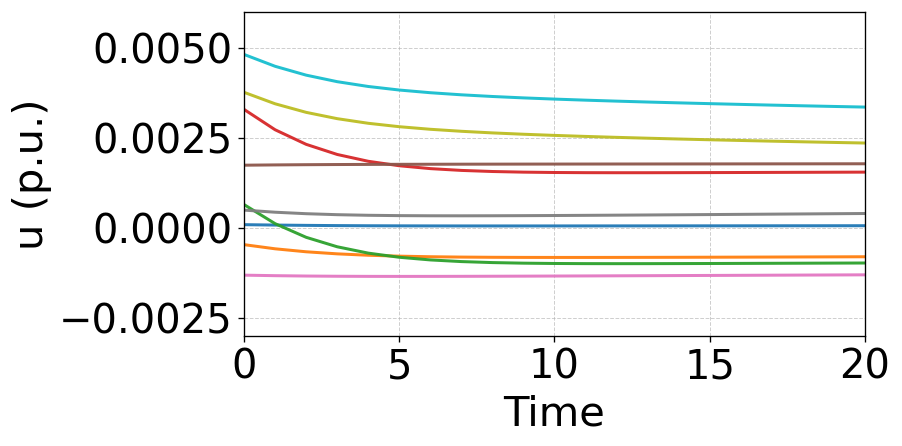

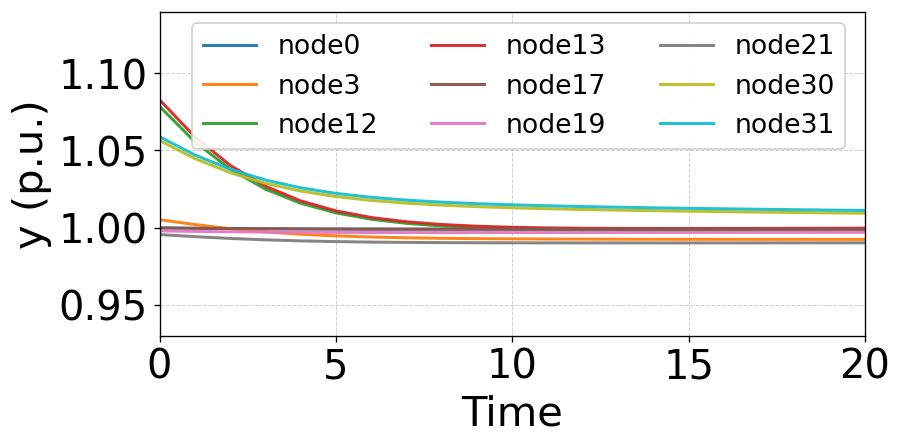

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/809291293.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


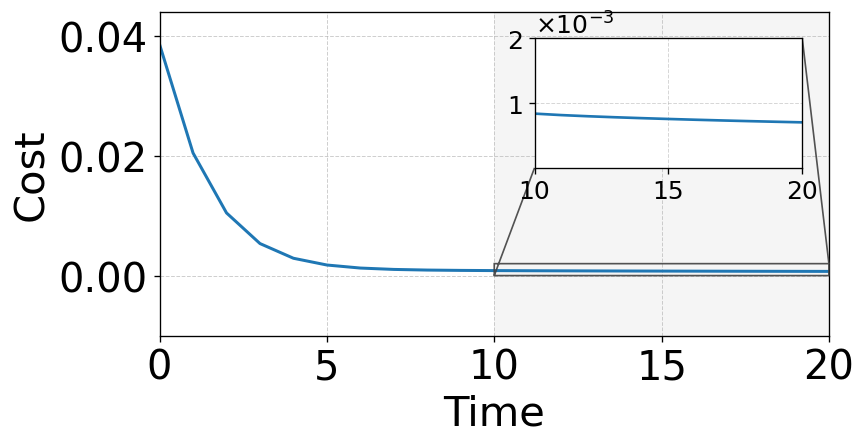

Saved to:
 - figures_static/GD_actions-static_9nodes.pdf
 - figures_static/GD_voltages-static_9nodes.pdf
 - figures_static/GD_cost-static.pdf


In [13]:
print('Feedback Optimization')

MANUAL_Y = {
    "action":  (-0.003, 0.006),
    "voltage": (0.93, 1.140),
    "cost":   (-0.01, 0.044),
}
FORCE_SYMM = {
    "action":  False,
    "voltage": False,
    "cost":    False,
}

Trajectory_Linear_gd = np.squeeze(np.asarray(Trajectory_Linear_gd))
Record_u_Linear_gd   = np.squeeze(np.asarray(Record_u_Linear_gd))
record_cost_gd       = np.asarray(record_cost_gd).ravel()

N_total = Record_u_Linear_gd.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost     = max(0, Sens_length - 1)
idx_cost       = slice(start_cost, N_total)
time_seg_cost  = np.arange(0, Opt_length_pretty + 1)

zoom_range = (10, 20)
os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

Y_action  = Record_u_Linear_gd[idx_opt, :]
Y_voltage = Trajectory_Linear_gd[idx_opt, :]
Y_cost    = record_cost_gd[idx_cost]

ylim_action  = compute_ylim([Y_action],  MANUAL_Y["action"],  pad_frac=0.06, symmetric=FORCE_SYMM["action"])
ylim_voltage = compute_ylim([Y_voltage], MANUAL_Y["voltage"], pad_frac=0.03, symmetric=FORCE_SYMM["voltage"])
ylim_cost    = compute_ylim([Y_cost],    MANUAL_Y["cost"],    pad_frac=0.08, symmetric=FORCE_SYMM["cost"])
xticks_main = np.arange(0, Opt_length_pretty + 1, 5)

sel_path = os.path.join(out_dir, "plotted_nodes.npy")
selected_node_ids = np.load(sel_path)
T_opt, n_ctrl = Y_voltage.shape

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    controlled_nodes_arr = np.asarray(controlled_nodes, dtype=int)
    selected_cols = []
    for nid in selected_node_ids:
        matches = np.where(controlled_nodes_arr == nid)[0]
        if matches.size == 0:
            raise ValueError(f"Node ID {nid} not found in controlled_nodes for GD.")
        selected_cols.append(matches[0])
    selected_cols = np.asarray(selected_cols, dtype=int)
    node_ids_for_plot = np.asarray(selected_node_ids, dtype=int)
else:
    selected_cols = np.asarray(selected_node_ids, dtype=int)
    node_ids_for_plot = selected_cols

Y_action_sel  = Y_action[:, selected_cols]
Y_voltage_sel = Y_voltage[:, selected_cols]

cmap   = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("u (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)


plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "GD_actions-static_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("y (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

vmin, vmax = ax.get_ylim()
vstep = 0.05
vstart = np.ceil(vmin / vstep) * vstep
vy = np.arange(vstart, vmax + 1e-12, vstep)
ax.set_yticks(np.round(vy, 3))

leg = ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=16
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "GD_voltages-static_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)

x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color='grey', alpha=0.08, linewidth=0)
add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(1e-5, 2e-3),
)


plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "GD_cost-static.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")

# Data-Driven Succ Linearization

In [14]:
dis_vv_controllers = DistributedVoltVarController(config_loader)
controlled_nodes = np.asarray(dis_vv_controllers.nodes, dtype=int).ravel()
dim_action = controlled_nodes.size

sol_list = []
record_cost_sc = []
Record_u_Linear_sc = []
record_grad_v_u = []
record_grad_u = []
Trajectory_Linear_sc = []

lr = 0.01
Iter_stop_criterier = 0.0005

p_init = np.asarray(p_init, float).reshape(-1, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)
new_p  = p_init.copy()
new_q  = q_init.copy()

for t in range(Sens_length):
    new_p = p_init
    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
    new_q[controlled_nodes] = q_init[controlled_nodes] + nu

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_sc.append(q_ctrl.ravel().copy())
    Trajectory_Linear_sc.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_sc.append(float(c))

decay_rate = 0.5
sens_coeff = 1 - np.exp(-decay_rate * np.arange(1, Sens_length))

for t in range(Sens_length, T):
    new_p = p_init

    if np.linalg.norm(grad_u) < 0.005:

        v_curr = get_v_ctrl_from_sol(sol_list[-1], controlled_nodes)

        grad_u = func_grad_u(
            v_curr,
            s_ref.reshape(1, -1),
            grad_v_u_estimate,
            new_q[controlled_nodes],
            c_action=C_ACTION,
            R_u=R_U
        )

        new_q[controlled_nodes] = Record_u_Linear_sc[-1].reshape(-1, 1) \
                                  + 0.01 * np.asarray(List_noise[:, t], float).reshape(-1, 1)
    else:
        U_win = np.asarray(Record_u_Linear_sc[t - Sens_length:t], dtype=float)
        V_win = np.asarray(
            np.squeeze(np.asarray(Trajectory_Linear_sc))[t - Sens_length:t],
            dtype=float
        )

        if U_win.ndim == 1:
            U_win = U_win.reshape(-1, 1)
        if V_win.ndim == 1:
            V_win = V_win.reshape(-1, 1)

        Diff_u = np.diff(U_win, axis=0)
        Diff_x = np.diff(V_win, axis=0)

        W = np.diag(sens_coeff)
        A = W @ Diff_u
        B = W @ Diff_x

        AtA = A.T @ A
        AtB = A.T @ B
        mu_base = 0
        scale = np.trace(AtA) / max(1, AtA.shape[0]) if AtA.size else 1.0
        mu = 0
        S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
        grad_v_u_estimate = S_T.T

        sol_curr = sol_list[-1]
        v_curr = get_v_ctrl_from_sol(sol_curr, controlled_nodes)

        grad_u = func_grad_u(
            v_curr,
            s_ref.reshape(1, -1),
            grad_v_u_estimate,
            new_q[controlled_nodes],
            c_action=C_ACTION,
            R_u=R_U
        )
        q_lin = cp.Variable((dim_action, 1))

        objective = cp.Minimize(
            0.5 * cp.norm(
                grad_v_u_estimate @ (q_lin - Record_u_Linear_sc[-1].reshape((-1, 1)))
                + Trajectory_Linear_sc[-1].reshape((-1, 1)) - s_ref.reshape((-1, 1))
            )
            + C_ACTION * cp.norm(q_lin)
        )

        if np.linalg.norm(grad_u) > 0.05:
            constraints = [
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 0.6 * float(np.linalg.norm(new_q[controlled_nodes])),
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 1.5 * float(np.linalg.norm(grad_u)),
                q_lin >= -Q_ABS_MAX,
                q_lin <= Q_ABS_MAX,
            ]
        elif np.linalg.norm(grad_u) > 0.01:
            constraints = [
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 0.4 * float(np.linalg.norm(new_q[controlled_nodes])),
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 1.5 * float(np.linalg.norm(grad_u)),
                q_lin >= -Q_ABS_MAX,
                q_lin <= Q_ABS_MAX,
            ]
        else:
            constraints = [
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 15 * float(np.linalg.norm(grad_u)) * float(np.linalg.norm(new_q[controlled_nodes])),
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 60 * (float(np.linalg.norm(grad_u)) ** 1) * float(np.linalg.norm(grad_u)),
                q_lin >= -Q_ABS_MAX,
                q_lin <= Q_ABS_MAX,
            ]

        prob = cp.Problem(objective, constraints)
        result = prob.solve()

        if (result is None) or np.isnan(result):
            print('NaN occurs')
            q_next = new_q[controlled_nodes] - lr * np.asarray(grad_u, dtype=float).reshape((-1, 1))
        else:
            q_next = np.array(q_lin.value).reshape((-1, 1))

        new_q[controlled_nodes] = np.clip(
            q_next + 0.01 * np.asarray(List_noise[:, t], float).reshape((-1, 1)),
            -Q_ABS_MAX,
            Q_ABS_MAX
        )

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_sc.append(q_ctrl.ravel().copy())
    Trajectory_Linear_sc.append(v_ctrl.copy())
    record_cost_sc.append(
        func_cost1(
            v_ctrl,
            s_ref.reshape(1, -1),
            q_ctrl,
            c_action=C_ACTION,
            R_u=R_U
        )
    )


Successive Linearization


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/1615059303.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(selected_cols))


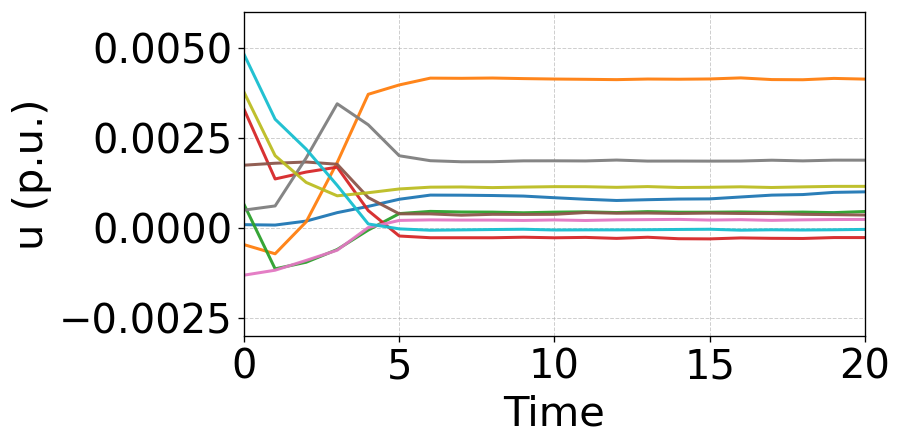

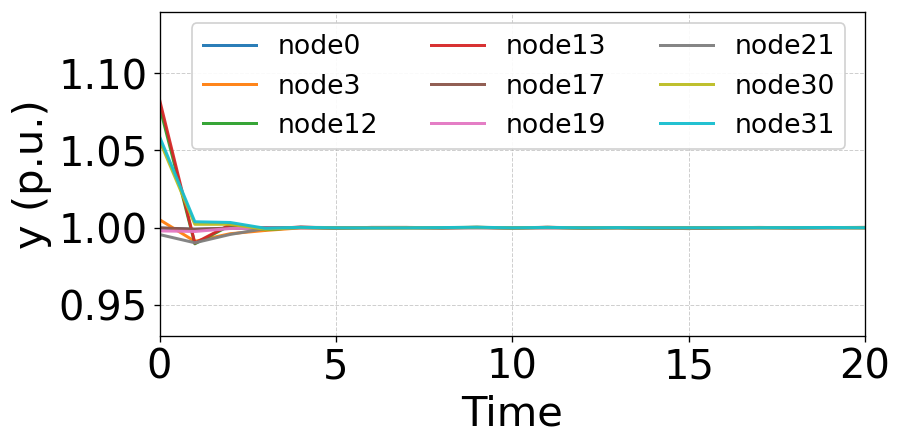

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/1615059303.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


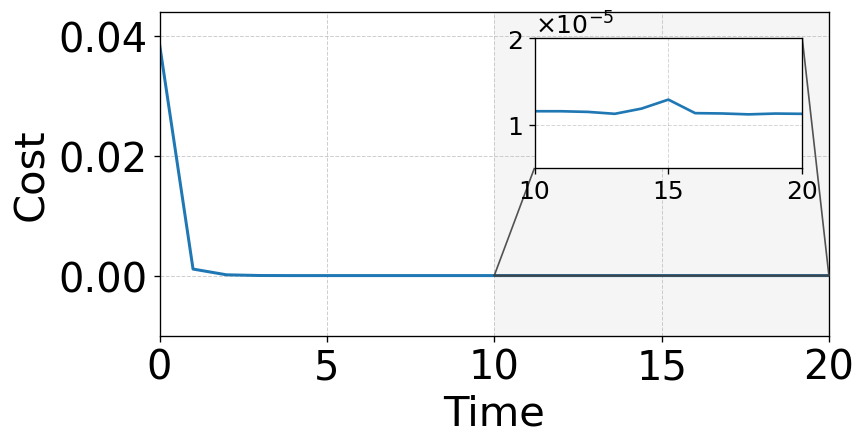

Saved to:
 - figures_static/SC_actions-static_9nodes.pdf
 - figures_static/SC_voltages-static_9nodes.pdf
 - figures_static/SC_cost-static.pdf


In [15]:
print('Successive Linearization')

MANUAL_Y = {
    "action":  (-0.003, 0.006),
    "voltage": (0.93, 1.140),
    "cost":   (-0.01, 0.044),
}
FORCE_SYMM = {
    "action":  False,   
    "voltage": False,
    "cost":    False,
}

Trajectory_Linear_sc = np.squeeze(np.asarray(Trajectory_Linear_sc))
Record_u_Linear_sc   = np.squeeze(np.asarray(Record_u_Linear_sc))
record_cost_sc       = np.asarray(record_cost_sc).ravel()

N_total = Record_u_Linear_sc.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost    = max(0, Sens_length - 1)
idx_cost      = slice(start_cost, N_total)
time_seg_cost = np.arange(0, Opt_length_pretty + 1)

zoom_range = (10, 20)


os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})
xticks_main = np.arange(0, Opt_length_pretty + 1, 5)

Y_action  = Record_u_Linear_sc[idx_opt, :]
Y_voltage = Trajectory_Linear_sc[idx_opt, :]
Y_cost    = record_cost_sc[idx_cost]

ylim_action  = compute_ylim([Y_action],  MANUAL_Y["action"],  pad_frac=0.06, symmetric=FORCE_SYMM["action"])
ylim_voltage = compute_ylim([Y_voltage], MANUAL_Y["voltage"], pad_frac=0.03, symmetric=FORCE_SYMM["voltage"])
ylim_cost    = compute_ylim([Y_cost],    MANUAL_Y["cost"],    pad_frac=0.08, symmetric=FORCE_SYMM["cost"])
sel_path = os.path.join(out_dir, "plotted_nodes.npy")
selected_node_ids = np.load(sel_path)
T_opt, n_ctrl = Y_voltage.shape

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    controlled_nodes_arr = np.asarray(controlled_nodes, dtype=int)
    selected_cols = []
    for nid in selected_node_ids:
        matches = np.where(controlled_nodes_arr == nid)[0]
        if matches.size == 0:
            raise ValueError(f"Node ID {nid} not found in controlled_nodes for SC.")
        selected_cols.append(matches[0])
    selected_cols = np.asarray(selected_cols, dtype=int)
    node_ids_for_plot = np.asarray(selected_node_ids, dtype=int)
else:
    selected_cols = np.asarray(selected_node_ids, dtype=int)
    node_ids_for_plot = selected_cols

Y_action_sel  = Y_action[:, selected_cols]
Y_voltage_sel = Y_voltage[:, selected_cols]

cmap   = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("u (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)


plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "SC_actions-static_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("y (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

vmin, vmax = ax.get_ylim()
vstep = 0.05
vstart = np.ceil(vmin / vstep) * vstep
vy = np.arange(vstart, vmax + 1e-12, vstep)
ax.set_yticks(np.round(vy, 3))

leg = ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=16
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "SC_voltages-static_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)

x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color='grey', alpha=0.08, linewidth=0)
add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(0.5e-5, 2e-5),
)


plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "SC_cost-static.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")

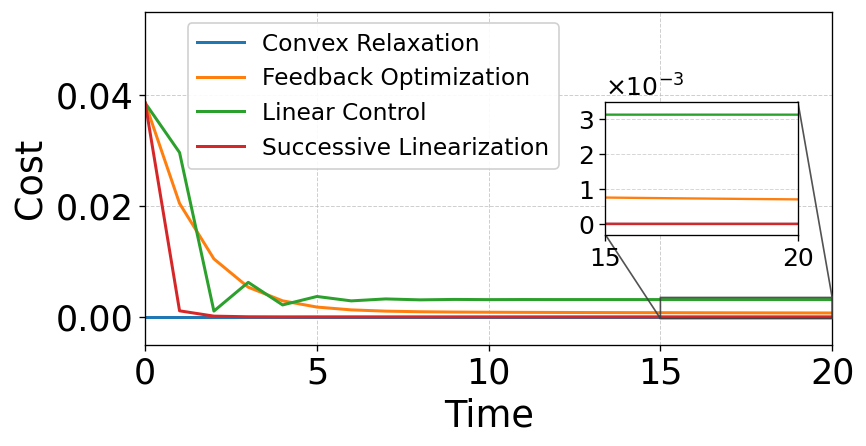

Joint cost figure saved to: figures_static/ALL_methods_cost-static.pdf


In [16]:
def add_zoom_inset_auto(
    ax, x, Y, x_zoom=(20, 30), size=0.35,
    loc_candidates=("upper right", "upper left", "lower left", "lower right"),
    *,
    inset_ticklabelsize: int = 15,
    inset_ylim=None,
    manual_bbox=None,
):
    x = np.asarray(x)
    Y = np.asarray(Y)
    if Y.ndim == 1:
        y_rep = Y
    else:
        y_rep = np.median(Y, axis=1)

    if manual_bbox is not None:
        iax = ax.inset_axes(manual_bbox, transform=ax.transAxes)
        best_loc = None
    else:
        ax.figure.canvas.draw()
        xL, xR = ax.get_xlim()
        yB, yT = ax.get_ylim()
        xW, yH = (xR - xL), (yT - yB)
        box_w, box_h = xW * size, yH * size
        candidates = {
            "upper right":  ((xR - box_w, xR), (yT - box_h, yT)),
            "upper left":   ((xL, xL + box_w), (yT - box_h, yT)),
            "lower left":   ((xL, xL + box_w), (yB, yB + box_h)),
            "lower right":  ((xR - box_w, xR), (yB, yB + box_h)),
        }
        best_loc, best_score = None, None
        for loc in loc_candidates:
            (cx0, cx1), (cy0, cy1) = candidates[loc]
            mask = (x >= cx0) & (x <= cx1) & (y_rep >= cy0) & (y_rep <= cy1)
            score = int(np.count_nonzero(mask))
            if best_score is None or score < best_score:
                best_score, best_loc = score, loc

        iax = inset_axes(
            ax,
            width=f"{int(size * 100)}%",
            height=f"{int(size * 100)}%",
            loc=best_loc,
            borderpad=1.0,
        )

    if Y.ndim == 2:
        iax.plot(x, Y, lw=1.4)
    else:
        iax.plot(x, Y, lw=1.4)

    x0, x1 = x_zoom
    iax.set_xlim(x0, x1)

    iax.xaxis.set_major_locator(MultipleLocator(5))

    if inset_ylim is not None:
        iax.set_ylim(inset_ylim[0], inset_ylim[1])
    else:
        zmask = (x >= x0) & (x <= x1)
        if np.any(zmask):
            if Y.ndim == 2:
                y_min = float(np.min(Y[zmask, :]))
                y_max = float(np.max(Y[zmask, :]))
            else:
                y_min = float(np.min(Y[zmask]))
                y_max = float(np.max(Y[zmask]))
            pad = 0.10 * (y_max - y_min + 1e-12)
            iax.set_ylim(y_min - pad, y_max + pad)

    iax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    iax.tick_params(axis="both", labelsize=inset_ticklabelsize)

    yfmt = ScalarFormatter(useMathText=True)
    yfmt.set_scientific(True)
    yfmt.set_powerlimits((-3, 3))
    yfmt.set_useOffset(False)
    iax.yaxis.set_major_formatter(yfmt)
    iax.yaxis.get_offset_text().set_fontsize(inset_ticklabelsize)

    try:
        ax.indicate_inset_zoom(iax, edgecolor="0.25", alpha=0.9)
    except Exception:
        pass

    return iax, best_loc
record_cost_sc  = np.asarray(record_cost_sc).ravel()
record_cost_lin = np.asarray(record_cost_lin).ravel()
record_cost_gd  = np.asarray(record_cost_gd).ravel()
record_cost_cvc = np.asarray(record_cost_cvc).ravel()

N_common = min(
    record_cost_sc.size,
    record_cost_lin.size,
    record_cost_gd.size,
    record_cost_cvc.size,
)
record_cost_sc  = record_cost_sc[:N_common]
record_cost_lin = record_cost_lin[:N_common]
record_cost_gd  = record_cost_gd[:N_common]
record_cost_cvc = record_cost_cvc[:N_common]

Opt_length_pretty = N_common - Sens_length
start_cost        = max(0, Sens_length - 1)
idx_cost          = slice(start_cost, N_common)
time_seg_cost     = np.arange(0, Opt_length_pretty + 1)

Y_cost_sc  = record_cost_sc[idx_cost]
Y_cost_lin = record_cost_lin[idx_cost]
Y_cost_gd  = record_cost_gd[idx_cost]
Y_cost_cvc = record_cost_cvc[idx_cost].copy()

if Y_cost_cvc.size >= 2:
    Y_cost_cvc[0] = Y_cost_cvc[1]

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
})

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)

ax.plot(time_seg_cost, Y_cost_cvc,  lw=1.8, label="Convex Relaxation")
ax.plot(time_seg_cost, Y_cost_gd,   lw=1.8, label="Feedback Optimization")
ax.plot(time_seg_cost, Y_cost_lin,  lw=1.8, label="Linear Control")
ax.plot(time_seg_cost, Y_cost_sc,   lw=1.8, label="Successive Linearization")

ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(np.arange(0, Opt_length_pretty + 1, 5))
ax.set_ylim(-0.005, 0.055)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.055, 0.98),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.9,
    ncol=1,
    fontsize=14,
)

Y_all = np.column_stack([Y_cost_cvc, Y_cost_gd, Y_cost_lin, Y_cost_sc])

k_last = 5
x0_last = max(0, Opt_length_pretty - k_last)
x1_last = Opt_length_pretty

manual_bbox = [0.67, 0.33, 0.28, 0.40]

iax, _ = add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_all,
    x_zoom=(x0_last, x1_last),
    size=0.30,
    inset_ylim=None,
    manual_bbox=manual_bbox,
)

ymin, _ = iax.get_ylim()
iax.set_ylim(ymin, 0.0035)
iax.yaxis.set_major_locator(MultipleLocator(0.001))

plt.tight_layout()
out_pdf_joint = os.path.join(out_dir, "ALL_methods_cost-static.pdf")
plt.savefig(out_pdf_joint, format="pdf", bbox_inches="tight")
plt.show()

print("Joint cost figure saved to:", out_pdf_joint)

# Experiments

In [17]:
class GdExperiment:
    def __init__(
        self,
        pf_model,
        p_init: np.ndarray,
        q_init: np.ndarray,
        controlled_nodes: np.ndarray,
        func_cost1,
        func_grad_u,
        Sens_length: int,
        Opt_length: int,
        s_ref: np.ndarray,
        C_ACTION: float,
        R_U: Optional[np.ndarray],
        Q_ABS_MAX: float,
        lr0: float = 2e-4,
        decay_rate_lr: float = 0.001
    ):
        self.pf_model = pf_model
        self.p_init = np.asarray(p_init, float).reshape(-1, 1).copy()
        self.q_init = np.asarray(q_init, float).reshape(-1, 1).copy()
        self.q_init.setflags(write=False)

        self.controlled_nodes = np.asarray(controlled_nodes, int).ravel()
        self.func_cost1 = func_cost1
        self.func_grad_u = func_grad_u

        self.Sens_length = int(Sens_length)
        self.Opt_length = int(Opt_length)
        self.T = self.Sens_length + self.Opt_length

        self.s_ref = np.asarray(s_ref, float)
        if self.s_ref.ndim == 1:
            self.s_ref = self.s_ref.reshape(1, -1)
        elif self.s_ref.ndim == 2 and self.s_ref.shape[0] != 1:
            self.s_ref = self.s_ref.reshape(1, -1)

        self.C_ACTION = float(C_ACTION)
        self.R_U = R_U
        self.Q_ABS_MAX = float(Q_ABS_MAX)

        self.lr0 = float(lr0)
        self.decay_rate_lr = float(decay_rate_lr)

        self.decay_rate = 0.5
        if self.Sens_length > 0:
            self.sens_coeff = 1.0 - np.exp(-self.decay_rate * np.arange(1, self.Sens_length))
        else:
            self.sens_coeff = np.array([], dtype=float)

    @staticmethod
    def _has_nan(x) -> bool:
        return np.isnan(np.asarray(x, dtype=float)).any()

    def _get_v_ctrl_from_sol(self, sol: dict) -> np.ndarray:
        v_all = np.asarray(sol['v'], dtype=float).ravel()
        m = self.controlled_nodes.size

        if v_all.size == m:
            idx = self.controlled_nodes
        elif v_all.size == m + 1:
            idx = self.controlled_nodes + 1
        else:
            raise ValueError(
                f"Unexpected v length {v_all.size} for m={m} controlled nodes."
            )

        return v_all[idx].reshape(1, -1)

    def run_fixed_p_with_qnoise(
        self,
        List_noise: np.ndarray,
        verbose: bool = False
    ) -> Dict[str, Any]:
        controlled_nodes = self.controlled_nodes
        m = controlled_nodes.size
        p_init = self.p_init.copy()
        q_init = self.q_init.copy()
        new_q  = q_init.copy()

        if verbose:
            print('p_init before: ', p_init.T)
            print('q_init before: ', q_init[controlled_nodes].T)

        sol_list: List[dict] = []
        record_cost_gd: List[float] = []
        Record_u_Linear_gd: List[np.ndarray] = []
        Trajectory_Linear_gd: List[np.ndarray] = []
        record_grad_v_u: List[np.ndarray] = []
        record_grad_u:   List[np.ndarray] = []

        for t in range(self.Sens_length):
            new_p = p_init

            nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
            new_q[controlled_nodes] = q_init[controlled_nodes] + nu

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_gd.append(q_ctrl.ravel().copy())
            Trajectory_Linear_gd.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref,
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U
            )
            record_cost_gd.append(float(c))

        sens_coeff = self.sens_coeff

        for t in range(self.Sens_length, self.T):
            lr = self.lr0 * np.exp(-self.decay_rate_lr * t)
            new_p = p_init

            U_win = np.asarray(Record_u_Linear_gd[t - self.Sens_length:t], float)
            V_win = np.asarray(
                np.squeeze(np.asarray(Trajectory_Linear_gd))[t - self.Sens_length:t],
                float
            )

            Diff_u = np.diff(U_win, axis=0)
            Diff_x = np.diff(V_win, axis=0)
            if Diff_u.ndim == 1:
                Diff_u = Diff_u.reshape(-1, 1)
            if Diff_x.ndim == 1:
                Diff_x = Diff_x.reshape(-1, 1)

            if sens_coeff.size:
                W = np.diag(sens_coeff)
                A = W @ Diff_u
                B = W @ Diff_x
            else:
                A = Diff_u
                B = Diff_x

            AtA = A.T @ A
            AtB = A.T @ B
            mu = 0.0
            S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
            J_v_u_estimate = S_T.T
            sol_curr = sol_list[-1]
            v_curr = self._get_v_ctrl_from_sol(sol_curr)

            grad_u = self.func_grad_u(
                v_curr,
                self.s_ref,
                J_v_u_estimate,
                new_q[controlled_nodes],
                c_action=self.C_ACTION,
                R_u=self.R_U
            )
            if self._has_nan(grad_u):
                if verbose:
                    print(' grad_u nan, break at t=', t)
                break

            q_next = new_q[controlled_nodes] - lr * np.asarray(grad_u, float).reshape((-1, 1))
            new_q[controlled_nodes] = np.clip(q_next, -self.Q_ABS_MAX, self.Q_ABS_MAX)

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            if self._has_nan(v_ctrl):
                if verbose:
                    print(' v nan, break at t=', t)
                break

            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_gd.append(q_ctrl.ravel().copy())
            Trajectory_Linear_gd.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref,
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U
            )
            record_cost_gd.append(float(c))

            record_grad_v_u.append(np.asarray(J_v_u_estimate, float))
            record_grad_u.append(np.asarray(grad_u, float).reshape(-1, 1))

        if verbose:
            print(' p_init after: ', p_init.T)
            print(' q_init after: ', self.q_init[controlled_nodes].T)

        return {
            "sol_list": sol_list,
            "record_cost_gd": record_cost_gd,
            "Record_u_Linear_gd": Record_u_Linear_gd,
            "Trajectory_Linear_gd": Trajectory_Linear_gd,
            "record_grad_v_u": record_grad_v_u,
            "record_grad_u": record_grad_u,
        }


In [18]:
class ScExperiment:
    def __init__(
        self,
        pf_model,
        p_init: np.ndarray,
        q_init: np.ndarray,
        controlled_nodes: np.ndarray,
        func_cost1,
        func_grad_u,
        Sens_length: int,
        Opt_length: int,
        s_ref: np.ndarray,
        C_ACTION: float,
        R_U: Optional[np.ndarray],
        Q_ABS_MAX: float,
        lr: float = 0.01,
        decay_rate: float = 0.5
    ):
        self.pf_model = pf_model
        self.p_init = np.asarray(p_init, float).reshape(-1, 1).copy()
        self.q_init = np.asarray(q_init, float).reshape(-1, 1).copy()
        self.q_init.setflags(write=False)

        self.controlled_nodes = np.asarray(controlled_nodes, int).ravel()
        self.dim_action = int(self.controlled_nodes.size)

        self.func_cost1 = func_cost1
        self.func_grad_u = func_grad_u

        self.Sens_length = int(Sens_length)
        self.Opt_length = int(Opt_length)
        self.T = self.Sens_length + self.Opt_length

        self.s_ref = np.asarray(s_ref, float)
        if self.s_ref.ndim == 1:
            self.s_ref = self.s_ref.reshape(1, -1)
        elif self.s_ref.ndim == 2 and self.s_ref.shape[0] != 1:
            self.s_ref = self.s_ref.reshape(1, -1)

        self.C_ACTION = float(C_ACTION)
        self.R_U = R_U
        self.Q_ABS_MAX = float(Q_ABS_MAX)

        self.lr = float(lr)
        self.decay_rate = float(decay_rate)

        if self.Sens_length > 0:
            self.sens_coeff = 1.0 - np.exp(
                -self.decay_rate * np.arange(1, self.Sens_length)
            )
        else:
            self.sens_coeff = np.array([], dtype=float)


    @staticmethod
    def _has_nan(x) -> bool:
        return np.isnan(np.asarray(x, float)).any()

    def _get_v_ctrl_from_sol(self, sol: dict) -> np.ndarray:
        v_all = np.asarray(sol["v"], float).ravel()
        m = self.controlled_nodes.size

        if v_all.size == m:
            idx = self.controlled_nodes
        elif v_all.size == m + 1:
            idx = self.controlled_nodes + 1
        else:
            raise ValueError(
                f" Unexpected v length {v_all.size} for m={m} controlled nodes."
            )

        return v_all[idx].reshape(1, -1)


    def run_fixed_p_with_qnoise(
        self,
        List_noise: np.ndarray,
        verbose: bool = False,
    ) -> Dict[str, Any]:
        controlled_nodes = self.controlled_nodes
        m = self.dim_action

        p_init = self.p_init.copy()
        q_init = self.q_init.copy()
        new_q = q_init.copy()

        if verbose:
            print("p_init before : ", p_init.T)
            print("q_init before : ", q_init[controlled_nodes].T)

        sol_list: List[dict] = []
        record_cost_sc: List[float] = []
        Record_u_Linear_sc: List[np.ndarray] = []
        Trajectory_Linear_sc: List[np.ndarray] = []
        record_grad_v_u: List[np.ndarray] = []
        record_grad_u: List[np.ndarray] = []

        grad_u = np.ones((m, 1), float)
        grad_v_u_estimate = np.eye(m, dtype=float)

        for t in range(self.Sens_length):
            new_p = p_init

            nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
            new_q[controlled_nodes] = q_init[controlled_nodes] + nu

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_sc.append(q_ctrl.ravel().copy())
            Trajectory_Linear_sc.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref,
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_sc.append(float(c))

        sens_coeff = self.sens_coeff

        for t in range(self.Sens_length, self.T):
            new_p = p_init

            if np.linalg.norm(grad_u) < 0.005:

                v_curr = self._get_v_ctrl_from_sol(sol_list[-1])

                grad_u = self.func_grad_u(
                    v_curr,
                    self.s_ref,
                    grad_v_u_estimate,
                    new_q[controlled_nodes],
                    c_action=self.C_ACTION,
                    R_u=self.R_U,
                )

                new_q[controlled_nodes] = (
                    Record_u_Linear_sc[-1].reshape(-1, 1)
                    + 0.01 * np.asarray(List_noise[:, t], float).reshape(-1, 1)
                )

            else:
                U_win = np.asarray(
                    Record_u_Linear_sc[t - self.Sens_length : t], dtype=float
                )
                V_win = np.asarray(
                    np.squeeze(np.asarray(Trajectory_Linear_sc))[
                        t - self.Sens_length : t
                    ],
                    dtype=float,
                )

                U_win = np.squeeze(U_win)
                V_win = np.squeeze(V_win)
                if U_win.ndim == 1:
                    U_win = U_win.reshape(-1, 1)
                if V_win.ndim == 1:
                    V_win = V_win.reshape(-1, 1)

                Diff_u = np.diff(U_win, axis=0)
                Diff_x = np.diff(V_win, axis=0)

                if sens_coeff.size:
                    W = np.diag(sens_coeff)
                    A = W @ Diff_u
                    B = W @ Diff_x
                else:
                    A, B = Diff_u, Diff_x

                AtA = A.T @ A
                AtB = A.T @ B
                mu = 0.0

                try:
                    S_T = np.linalg.solve(
                        AtA + mu * np.eye(AtA.shape[0]), AtB
                    )
                except np.linalg.LinAlgError:
                    if verbose:
                        print("NaN occurs", t)
                    v_curr = self._get_v_ctrl_from_sol(sol_list[-1])
                    grad_u = self.func_grad_u(
                        v_curr,
                        self.s_ref,
                        grad_v_u_estimate,
                        new_q[controlled_nodes],
                        c_action=self.C_ACTION,
                        R_u=self.R_U,
                    )
                    q_next = new_q[controlled_nodes] - self.lr * np.asarray(
                        grad_u, float
                    ).reshape(-1, 1)
                    new_q[controlled_nodes] = np.clip(
                        q_next, -self.Q_ABS_MAX, self.Q_ABS_MAX
                    )
                    sol = self.pf_model.runpf(new_p, new_q)
                    sol_list.append(sol)
                    v_ctrl = self._get_v_ctrl_from_sol(sol)
                    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)
                    Record_u_Linear_sc.append(q_ctrl.ravel().copy())
                    Trajectory_Linear_sc.append(v_ctrl.copy())
                    record_cost_sc.append(
                        self.func_cost1(
                            v_ctrl,
                            self.s_ref,
                            q_ctrl,
                            c_action=self.C_ACTION,
                            R_u=self.R_U,
                        )
                    )
                    record_grad_u.append(np.asarray(grad_u, float).reshape(-1, 1))
                    continue

                grad_v_u_estimate = S_T.T

                sol_curr = sol_list[-1]
                v_curr = self._get_v_ctrl_from_sol(sol_curr)

                grad_u = self.func_grad_u(
                    v_curr,
                    self.s_ref,
                    grad_v_u_estimate,
                    new_q[controlled_nodes],
                    c_action=self.C_ACTION,
                    R_u=self.R_U,
                )

                if verbose:
                    try:
                        eig_min = np.min(np.linalg.eigvals(AtA))
                        print(" eigen_min(AtA) =", eig_min)
                    except Exception:
                        pass
                    print(" grad_u norm =", np.linalg.norm(grad_u))

                q_lin = cp.Variable((m, 1))

                objective = cp.Minimize(
                    0.5
                    * cp.norm(
                        grad_v_u_estimate
                        @ (q_lin - Record_u_Linear_sc[-1].reshape((-1, 1)))
                        + Trajectory_Linear_sc[-1].reshape((-1, 1))
                        - self.s_ref.reshape((-1, 1))
                    )
                    + self.C_ACTION * cp.norm(q_lin)
                )

                gnorm = float(np.linalg.norm(grad_u))
                qnorm = float(np.linalg.norm(new_q[controlled_nodes]))

                if gnorm > 0.05:
                    constraints = [
                        cp.norm(
                            q_lin - new_q[controlled_nodes].reshape((-1, 1))
                        )
                        <= 0.6 * qnorm,
                        cp.norm(
                            q_lin - new_q[controlled_nodes].reshape((-1, 1))
                        )
                        <= 1.5 * gnorm,
                        q_lin >= -self.Q_ABS_MAX,
                        q_lin <= self.Q_ABS_MAX,
                    ]
                elif gnorm > 0.01:
                    constraints = [
                        cp.norm(
                            q_lin - new_q[controlled_nodes].reshape((-1, 1))
                        )
                        <= 0.4 * qnorm,
                        cp.norm(
                            q_lin - new_q[controlled_nodes].reshape((-1, 1))
                        )
                        <= 1.5 * gnorm,
                        q_lin >= -self.Q_ABS_MAX,
                        q_lin <= self.Q_ABS_MAX,
                    ]
                else:
                    constraints = [
                        cp.norm(
                            q_lin - new_q[controlled_nodes].reshape((-1, 1))
                        )
                        <= 15.0 * gnorm * qnorm,
                        cp.norm(
                            q_lin - new_q[controlled_nodes].reshape((-1, 1))
                        )
                        <= 60.0 * (gnorm**1) * gnorm,
                        q_lin >= -self.Q_ABS_MAX,
                        q_lin <= self.Q_ABS_MAX,
                    ]

                prob = cp.Problem(objective, constraints)
                result = prob.solve()

                if (result is None) or np.isnan(result):
                    if verbose:
                        print(" NaN occurs (t=", t, ")")
                    q_next = new_q[controlled_nodes] - self.lr * np.asarray(
                        grad_u, float
                    ).reshape(-1, 1)
                else:
                    q_next = np.array(q_lin.value, float).reshape(-1, 1)

                new_q[controlled_nodes] = np.clip(
                    q_next
                    + 0.01
                    * np.asarray(List_noise[:, t], float).reshape(-1, 1),
                    -self.Q_ABS_MAX,
                    self.Q_ABS_MAX,
                )

                record_grad_v_u.append(np.asarray(grad_v_u_estimate, float))
                record_grad_u.append(np.asarray(grad_u, float).reshape(-1, 1))

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_sc.append(q_ctrl.ravel().copy())
            Trajectory_Linear_sc.append(v_ctrl.copy())
            record_cost_sc.append(
                self.func_cost1(
                    v_ctrl,
                    self.s_ref,
                    q_ctrl,
                    c_action=self.C_ACTION,
                    R_u=self.R_U,
                )
            )

        if verbose:
            print("p_init after  : ", p_init.T)
            print("q_init after  : ", self.q_init[controlled_nodes].T)

        return {
            "sol_list": sol_list,
            "record_cost_sc": record_cost_sc,
            "Record_u_Linear_sc": Record_u_Linear_sc,
            "Trajectory_Linear_sc": Trajectory_Linear_sc,
            "record_grad_v_u": record_grad_v_u,
            "record_grad_u": record_grad_u,
        }


In [19]:
class LcExperiment:


    def __init__(
        self,
        pf_model,
        p_init: np.ndarray,
        q_init: np.ndarray,
        controlled_nodes: np.ndarray,
        func_cost1,
        Sens_length: int,
        Opt_length: int,
        s_ref: np.ndarray,
        C_ACTION: float,
        R_U: Optional[np.ndarray],
        Q_ABS_MAX: float,
        k_file: str = "src/cases/pypower/case33/linear_k.pckl",
        index_mode_for_k: str = "reduced",
        v_set: float = 1.0,
        k_scale: float = 1.0,
        verbose: bool = False,
    ):
        self.pf_model = pf_model
        self.p_init = np.asarray(p_init, float).reshape(-1, 1).copy()
        self.q_init = np.asarray(q_init, float).reshape(-1, 1).copy()
        self.q_init.setflags(write=False)

        self.controlled_nodes = np.asarray(controlled_nodes, int).ravel()
        self.m = int(self.controlled_nodes.size)
        self.dim_action = self.m

        self.func_cost1 = func_cost1
        self.Sens_length = int(Sens_length)
        self.Opt_length = int(Opt_length)
        self.T = self.Sens_length + self.Opt_length

        self.s_ref = np.asarray(s_ref, float)
        if self.s_ref.ndim == 1:
            self.s_ref = self.s_ref.reshape(1, -1)
        elif self.s_ref.ndim == 2 and self.s_ref.shape[0] != 1:
            self.s_ref = self.s_ref.reshape(1, -1)

        self.C_ACTION = float(C_ACTION)
        self.R_U = R_U
        self.Q_ABS_MAX = float(Q_ABS_MAX)

        self.v_set = float(v_set)
        self.k_file = k_file
        self.index_mode_for_k = index_mode_for_k
        self.k_scale = float(k_scale)
        self.verbose = verbose

        self.K_vec = self._load_kvec_from_pckl(
            self.k_file, self.controlled_nodes, self.index_mode_for_k
        )
        if self.K_vec.size != self.m:
            raise ValueError(f"K vector length {self.K_vec.size} != #controlled {self.m}")
        if not np.isfinite(self.K_vec).all():
            raise ValueError("K vector contains inf/NaN.")

        self.K_vec = (self.K_vec * self.k_scale).astype(float, copy=False)
        self.K = np.diag(self.K_vec)

        if self.verbose:
            print(
                f"[LC-K] loaded from {self.k_file}: shape={self.K_vec.shape}, "
                f"min={self.K_vec.min():.4g}, max={self.K_vec.max():.4g}"
            )


    @staticmethod
    def _as_1d_float_array(x):
        try:
            arr = np.asarray(x, dtype=float)
        except Exception:
            arr = np.asarray(getattr(x, "values", x), dtype=float)
        arr = np.squeeze(arr)
        if arr.ndim == 0:
            arr = arr.reshape(1,)
        if arr.ndim != 1:
            arr = arr.reshape(-1,)
        return arr

    def _load_kvec_from_pckl(
        self,
        path: str,
        controlled_nodes: np.ndarray,
        index_mode: str = "reduced"
    ) -> np.ndarray:
        if not os.path.exists(path):
            raise FileNotFoundError(f"K file not found: {path}")

        with open(path, "rb") as f:
            obj = pickle.load(f)

        m = controlled_nodes.size
        kvec = None
        k_full = None
        cn_in_file = None

        if isinstance(obj, dict):
            for key in ["k", "kvec", "K", "gain", "gains", "k_vector"]:
                if key in obj:
                    kvec = self._as_1d_float_array(obj[key])
                    break
            for key in ["k_full", "kbus", "full_k", "k_all_buses"]:
                if key in obj:
                    k_full = self._as_1d_float_array(obj[key])
                    break
            for key in ["controlled_nodes", "ctrl_nodes", "nodes"]:
                if key in obj:
                    cn_in_file = np.asarray(
                        obj["controlled_nodes" if "controlled_nodes" in obj else key],
                        dtype=int
                    ).ravel()
                    break

        elif isinstance(obj, (list, tuple)) and len(obj) > 0:
            first = self._as_1d_float_array(obj[0])
            if first.size == m:
                kvec = first
            else:
                k_full = first
            for elem in obj[1:]:
                if isinstance(elem, (list, tuple, np.ndarray)):
                    arr = np.asarray(elem)
                    if arr.ndim == 1 and arr.dtype.kind in "iu":
                        if arr.size == m:
                            cn_in_file = arr.astype(int)
                elif isinstance(elem, dict) and ("controlled_nodes" in elem):
                    cn_in_file = np.asarray(elem["controlled_nodes"], dtype=int).ravel()

        else:
            try:
                maybe = self._as_1d_float_array(obj)
                if maybe.size == m:
                    kvec = maybe
                else:
                    k_full = maybe
            except Exception as e:
                raise ValueError(f"Unrecognized K object in {path}: {type(obj)}") from e

        if kvec is not None:
            if (
                cn_in_file is not None
                and cn_in_file.size == m
                and not np.array_equal(cn_in_file, controlled_nodes)
            ):
                idx_map = {int(n): i for i, n in enumerate(cn_in_file)}
                try:
                    order = [idx_map[int(n)] for n in controlled_nodes]
                except KeyError as e:
                    raise ValueError(
                        f"controlled_nodes mismatch between file and current session: {e}"
                    )
                kvec = kvec[np.asarray(order, int)]
            return kvec

        if k_full is None:
            raise ValueError(
                f"No usable K found in {path}. Expect keys like 'k' or 'k_full'."
            )

        if index_mode == "reduced":
            take = np.asarray([int(n) + 1 for n in controlled_nodes], dtype=int)
        elif index_mode == "full":
            take = np.asarray(controlled_nodes, dtype=int)
        else:
            raise ValueError("index_mode must be 'reduced' or 'full'")

        if np.max(take) >= k_full.size:
            raise ValueError(
                f"k_full length {k_full.size} too small for max index {np.max(take)}"
            )
        return k_full[take]

    @staticmethod
    def _has_nan(x) -> bool:
        return np.isnan(np.asarray(x, float)).any()

    def _get_v_ctrl_from_sol(self, sol: dict) -> np.ndarray:
        v_all = np.asarray(sol["v"], float).ravel()
        m = self.m

        if v_all.size == m:
            idx = self.controlled_nodes
        elif v_all.size == m + 1:
            idx = self.controlled_nodes + 1
        else:
            raise ValueError(
                f"Unexpected v length {v_all.size} for m={m} controlled nodes."
            )

        return v_all[idx].reshape(1, -1)


    def run_fixed_p_with_qnoise(
        self,
        List_noise: np.ndarray,
        verbose: bool = False,
    ) -> Dict[str, Any]:

        controlled_nodes = self.controlled_nodes
        m = self.dim_action
        T = self.T
        Sens_length = self.Sens_length

        p_init = self.p_init.copy()
        q_init = self.q_init.copy()
        new_p  = p_init.copy()
        new_q  = q_init.copy()

        if verbose or self.verbose:
            print('p_init before: ', p_init.T)
            print('q_init before: ', q_init[controlled_nodes].T)

        sol_list: List[dict] = []
        record_cost_lin: List[float] = []
        Record_u_Linear_lin: List[np.ndarray] = []
        Trajectory_Linear_lin: List[np.ndarray] = []

        for t in range(Sens_length):
            new_p = p_init

            nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
            new_q[controlled_nodes] = q_init[controlled_nodes] + nu

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_lin.append(q_ctrl.ravel().copy())
            Trajectory_Linear_lin.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref,
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_lin.append(float(c))

        for t in range(Sens_length, T):
            new_p = p_init

            sol_last = sol_list[-1]
            v_ctrl_last = self._get_v_ctrl_from_sol(sol_last)

            err = (v_ctrl_last - self.s_ref).reshape(-1, 1)

            q_next = - (self.K @ err)
            q_next = np.clip(q_next, -self.Q_ABS_MAX, self.Q_ABS_MAX)

            new_q[controlled_nodes] = q_next
            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            if self._has_nan(v_ctrl):
                print('[Linear] v nan, break at t=', t)
                break

            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_lin.append(q_ctrl.ravel().copy())
            Trajectory_Linear_lin.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref,
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_lin.append(float(c))

        if verbose or self.verbose:
            print('p_init after : ', p_init.T)
            print('q_init after : ', q_init[controlled_nodes].T)

        return {
            "sol_list": sol_list,
            "record_cost_linear": record_cost_lin,
            "record_cost_linear_opt": record_cost_lin[Sens_length:],
            "Record_u_Linear_linear": Record_u_Linear_lin,
            "Trajectory_Linear_linear": Trajectory_Linear_lin,
        }


In [20]:
class CvcExperiment:

    def __init__(
        self,
        pf_model,
        cvc,
        p_init: np.ndarray,
        q_init: np.ndarray,
        s_ref: np.ndarray,
        *,
        Sens_length: int,
        T: int,
        C_ACTION: float,
        R_U: Optional[np.ndarray],
        Q_ABS_MAX: float,
        func_cost1,
        verbose: bool = False,
        replicate_tol: float = 1e-12,
    ):
        self.pf_model = pf_model
        self.cvc = cvc

        self.p0 = np.asarray(p_init, float).reshape(-1, 1).copy()
        self.q0 = np.asarray(q_init, float).reshape(-1, 1).copy()

        self.Sens_length = int(Sens_length)
        self.T = int(T)
        self.C_ACTION = float(C_ACTION)
        self.R_U = R_U
        self.Q_ABS_MAX = float(Q_ABS_MAX)
        self.func_cost1 = func_cost1
        self.verbose = bool(verbose)
        self.replicate_tol = float(replicate_tol)

        self.controlled_nodes = np.asarray(cvc.nodes, int).ravel()
        self._reduced = (self.controlled_nodes.size > 0 and int(np.min(self.controlled_nodes)) == 0)

        m = self.controlled_nodes.size
        s_ref = np.asarray(s_ref, float).ravel()
        if s_ref.size == m:
            self.s_ref_ctrl = s_ref.reshape(1, -1)
        else:
            if self._reduced:
                idx_full = np.array([k + 1 for k in self.controlled_nodes], int)
            else:
                idx_full = np.array(self.controlled_nodes, int)
            self.s_ref_ctrl = s_ref[idx_full].reshape(1, -1)

    def _one_step(
        self,
        new_p: np.ndarray,
        new_q: np.ndarray,
        sol_last_v: np.ndarray
    ):
        if self._reduced:
            v_dict = {int(k): float(sol_last_v[int(k) + 1]) for k in self.controlled_nodes}
        else:
            v_dict = {int(fb): float(sol_last_v[int(fb)]) for fb in self.controlled_nodes}

        q_total_dict = self.cvc.get_q(
            v_dict=v_dict,
            p=new_p.squeeze(),
            q=new_q.squeeze(),
            s_ref=self.s_ref_ctrl,
            c_action=self.C_ACTION,
            R_u=self.R_U,
            q_abs_max=self.Q_ABS_MAX,
            return_absolute=True,
            solver=None,
            verbose=False
        )

        q_total_t = new_q.copy()
        if self._reduced:
            for k, q_abs in q_total_dict.items():
                q_total_t[int(k), 0] = float(q_abs)
        else:
            for fb, q_abs in q_total_dict.items():
                q_total_t[int(fb) - 1, 0] = float(q_abs)

        sol = self.pf_model.runpf(new_p, q_total_t)

        if self._reduced:
            v_ctrl = np.array([sol['v'][int(k) + 1] for k in self.controlled_nodes], float).reshape(1, -1)
            q_ctrl_total = q_total_t[self.controlled_nodes, :].reshape(-1, 1)
            u_ctrl = (q_total_t - new_q)[self.controlled_nodes, :].reshape(-1, 1)
        else:
            idx = np.asarray(self.controlled_nodes, int) - 1
            v_ctrl = np.array([sol['v'][int(fb)] for fb in self.controlled_nodes], float).reshape(1, -1)
            q_ctrl_total = q_total_t[idx, :].reshape(-1, 1)
            u_ctrl = (q_total_t - new_q)[idx, :].reshape(-1, 1)

        cost_val = float(self.func_cost1(
            v_ctrl, self.s_ref_ctrl, q_ctrl_total,
            c_action=self.C_ACTION, R_u=self.R_U
        ))

        return sol, q_total_t, v_ctrl, q_ctrl_total, u_ctrl, cost_val

    def run_fixed_p(self) -> Dict[str, Any]:
        sol0 = self.pf_model.runpf(self.p0, self.q0)
        sol_list: List[dict] = [sol0]

        record_cost_cvc: List[float] = []
        Record_q_total_cvc: List[np.ndarray] = []
        Record_u_Linear_cvc: List[np.ndarray] = []
        Trajectory_Linear_cvc: List[np.ndarray] = []

        new_p = self.p0.copy()
        new_q = self.q0.copy()

        opt_len = max(0, self.T - self.Sens_length)
        if opt_len == 0:
            return {
                "sol_list": sol_list,
                "record_cost_centralized": record_cost_cvc,
                "Record_q_total_centralized": np.asarray(Record_q_total_cvc, float),
                "Record_u_Linear_centralized": np.asarray(Record_u_Linear_cvc, float),
                "Trajectory_Linear_centralized": np.asarray(Trajectory_Linear_cvc, float),
            }

        sol_1, q_total_t_1, v_ctrl_1, q_ctrl_total_1, u_ctrl_1, c_1 = self._one_step(new_p, new_q, sol_list[-1]['v'])
        sol_list.append(sol_1)
        Trajectory_Linear_cvc.append(v_ctrl_1)
        Record_q_total_cvc.append(q_ctrl_total_1.ravel())
        Record_u_Linear_cvc.append(u_ctrl_1.ravel())
        record_cost_cvc.append(c_1)

        if opt_len == 1:
            return {
                "sol_list": sol_list,
                "record_cost_centralized": record_cost_cvc,
                "Record_q_total_centralized": np.asarray(Record_q_total_cvc, float),
                "Record_u_Linear_centralized": np.asarray(Record_u_Linear_cvc, float),
                "Trajectory_Linear_centralized": np.asarray(Trajectory_Linear_cvc, float),
            }

        sol_2, q_total_t_2, v_ctrl_2, q_ctrl_total_2, u_ctrl_2, c_2 = self._one_step(new_p, new_q, sol_list[-1]['v'])
        sol_list.append(sol_2)
        Trajectory_Linear_cvc.append(v_ctrl_2)
        Record_q_total_cvc.append(q_ctrl_total_2.ravel())
        Record_u_Linear_cvc.append(u_ctrl_2.ravel())
        record_cost_cvc.append(c_2)

        same_q = np.allclose(q_total_t_2, q_total_t_1, rtol=0.0, atol=self.replicate_tol)
        same_v = np.allclose(v_ctrl_2, v_ctrl_1, rtol=0.0, atol=self.replicate_tol)

        if same_q and same_v:
            remain = opt_len - 2
            if remain > 0:
                last_sol = sol_list[-1]
                last_v_ctrl = Trajectory_Linear_cvc[-1].copy()
                last_q_total = Record_q_total_cvc[-1].copy()
                last_u_ctrl = Record_u_Linear_cvc[-1].copy()
                last_cost = record_cost_cvc[-1]

                sol_list.extend([last_sol] * remain)
                Trajectory_Linear_cvc.extend([last_v_ctrl.copy() for _ in range(remain)])
                Record_q_total_cvc.extend([last_q_total.copy() for _ in range(remain)])
                Record_u_Linear_cvc.extend([last_u_ctrl.copy() for _ in range(remain)])
                record_cost_cvc.extend([float(last_cost) for _ in range(remain)])
        else:
            new_q = q_total_t_2
            for _t in range(self.Sens_length + 2, self.T):
                sol_k, q_total_t_k, v_ctrl_k, q_ctrl_total_k, u_ctrl_k, c_k = self._one_step(new_p, new_q, sol_list[-1]['v'])
                sol_list.append(sol_k)
                Trajectory_Linear_cvc.append(v_ctrl_k)
                Record_q_total_cvc.append(q_ctrl_total_k.ravel())
                Record_u_Linear_cvc.append(u_ctrl_k.ravel())
                record_cost_cvc.append(c_k)
                new_q = q_total_t_k

        return {
            "sol_list": sol_list,
            "record_cost_centralized": record_cost_cvc,
            "Record_q_total_centralized": np.asarray(Record_q_total_cvc, float),
            "Record_u_Linear_centralized": np.asarray(Record_u_Linear_cvc, float),
            "Trajectory_Linear_centralized": np.asarray(Trajectory_Linear_cvc, float),
        }


In [21]:
_required_classes = ["GdExperiment", "ScExperiment", "CvcExperiment", "LcExperiment"]
_missing = [c for c in _required_classes if c not in globals()]
if _missing:
    raise NameError(f"missing {_missing}")

_required_syms = ["pf_model", "p_init", "q_init", "func_cost1", "func_grad_u", "config_loader", "my_case"]
_missing2 = [s for s in _required_syms if s not in globals()]
if _missing2:
    raise NameError(f"missing {_missing2}")

if "C_ACTION" not in globals():
    C_ACTION = 0.1
    warnings.warn("C_ACTION 0.1")
if "R_U" not in globals():
    R_U = None
    warnings.warn("R_U None")
if "Q_ABS_MAX" not in globals():
    Q_ABS_MAX = 0.05
    warnings.warn("Q_ABS_MAX 0.05")
if "Sens_length" not in globals():
    Sens_length = 100
    warnings.warn("Sens_length 100")
if "Opt_length" not in globals():
    Opt_length = 20
    warnings.warn("Opt_length 20")
if "sigma_e" not in globals():
    sigma_e = 0.01
    warnings.warn("sigma_e 0.01")
if "num_seeds" not in globals():
    num_seeds = 100
    warnings.warn("num_seeds 100")

p_init = np.asarray(p_init, dtype=float).reshape(-1, 1)
q_init = np.asarray(q_init, dtype=float).reshape(-1, 1)

dim_action = int(len(controlled_nodes))
n_bus_minus_1 = int(p_init.shape[0])
T = int(Sens_length + Opt_length)
SimulationLength = T

if "s_ref" not in globals():
    s_ref = np.ones((1, dim_action), dtype=float)
else:
    s_ref = np.asarray(s_ref, float)
    if s_ref.ndim == 1:
        s_ref = s_ref.reshape(1, -1)
    elif s_ref.ndim == 2 and s_ref.shape[0] != 1:
        s_ref = s_ref.reshape(1, -1)

cvc = CentralizedVoltVarController(model=pf_model, configLoader=config_loader)

ALL_RESULTS: Dict[str, Any] = {
    "meta": {
        "Sens_length": Sens_length,
        "Opt_length": Opt_length,
        "T": T,
        "C_ACTION": C_ACTION,
        "Q_ABS_MAX": Q_ABS_MAX,
        "R_U": R_U,
        "dim_action": dim_action,
        "controlled_nodes": np.asarray(controlled_nodes, int).copy(),
        "sigma_e": float(sigma_e),
        "num_seeds": int(num_seeds),
        "rng_seed_base": 42,
    },
    "per_seed": []
}

baseMVA = float(my_case["baseMVA"])
p_bus = np.asarray(my_case["bus"][1:, 2], float).reshape(-1, 1)
if p_bus.shape != p_init.shape:
    raise ValueError(f"p_bus shape {p_bus.shape} != p_init shape {p_init.shape}")

for seed_idx in range(int(num_seeds)):
    seed = 42 + seed_idx
    rng = np.random.default_rng(seed)

    p_step = -p_bus / baseMVA + 0.001 * rng.uniform(
        low=0.5, high=1.0, size=p_init.shape
    )

    zeros_state = np.zeros((n_bus_minus_1, T), dtype=float)

    List_noise_long = 0.1 * rng.normal(
        loc=0.0, scale=sigma_e, size=(dim_action, SimulationLength + 100)
    )
    noise_u_seed = np.asarray(List_noise_long[:, :T], float)


    lc_exp = LcExperiment(
        pf_model=pf_model,
        p_init=p_step,
        q_init=q_init,
        controlled_nodes=controlled_nodes,
        func_cost1=func_cost1,
        Sens_length=Sens_length,
        Opt_length=Opt_length,
        s_ref=s_ref,
        C_ACTION=C_ACTION,
        R_U=R_U,
        Q_ABS_MAX=Q_ABS_MAX,
    )

    gd_exp = GdExperiment(
        pf_model=pf_model,
        p_init=p_step,
        q_init=q_init,
        controlled_nodes=controlled_nodes,
        func_cost1=func_cost1,
        func_grad_u=func_grad_u,
        Sens_length=Sens_length,
        Opt_length=Opt_length,
        s_ref=s_ref,
        C_ACTION=C_ACTION,
        R_U=R_U,
        Q_ABS_MAX=Q_ABS_MAX,
        lr0=2e-4,
        decay_rate_lr=0.001,
    )

    sc_exp = ScExperiment(
        pf_model=pf_model,
        p_init=p_step,
        q_init=q_init,
        controlled_nodes=controlled_nodes,
        func_cost1=func_cost1,
        func_grad_u=func_grad_u,
        Sens_length=Sens_length,
        Opt_length=Opt_length,
        s_ref=s_ref,
        C_ACTION=C_ACTION,
        R_U=R_U,
        Q_ABS_MAX=Q_ABS_MAX,
        lr=0.01,
        decay_rate=0.5,
    )

    cvc_exp = CvcExperiment(
        pf_model=pf_model,
        cvc=cvc,
        p_init=p_step,
        q_init=q_init,
        s_ref=s_ref,
        Sens_length=Sens_length,
        T=T,
        C_ACTION=C_ACTION,
        R_U=R_U,
        Q_ABS_MAX=Q_ABS_MAX,
        func_cost1=func_cost1,
        verbose=False,
    )

    lc_logs = lc_exp.run_fixed_p_with_qnoise(
        List_noise=noise_u_seed,
        verbose=False,
    )
    lin_full = list(map(float, lc_logs["record_cost_linear"]))
    lin_opt  = lin_full[Sens_length:]
    lin_tail10_mean = tail_mean(lin_opt, tail_k=10)
    lin_tail5_mean  = tail_mean(lin_opt, tail_k=5)
    lin_first5_mean = head_mean(lin_opt, head_k=5)
    lin_first10_mean = head_mean(lin_opt, head_k=10)

    lin_opt_arr = np.asarray(lin_opt, float)
    k5_lin  = min(5, lin_opt_arr.size)
    k10_lin = min(10, lin_opt_arr.size)
    lin_first5_vals = lin_opt_arr[:k5_lin]
    lin_first10_vals = lin_opt_arr[:k10_lin]
    lin_tail5_vals  = lin_opt_arr[-k5_lin:]
    lin_tail10_vals = lin_opt_arr[-k10_lin:]

    gd_logs = gd_exp.run_fixed_p_with_qnoise(
        List_noise=noise_u_seed,
        verbose=False
    )
    gd_full = list(map(float, gd_logs["record_cost_gd"]))
    gd_opt  = gd_full[Sens_length:]
    gd_tail10_mean = tail_mean(gd_opt, tail_k=10)
    gd_tail5_mean  = tail_mean(gd_opt, tail_k=5)
    gd_first5_mean = head_mean(gd_opt, head_k=5)
    gd_first10_mean = head_mean(gd_opt, head_k=10)

    gd_opt_arr = np.asarray(gd_opt, float)
    k5_gd  = min(5, gd_opt_arr.size)
    k10_gd = min(10, gd_opt_arr.size)
    gd_first5_vals = gd_opt_arr[:k5_gd]
    gd_first10_vals = gd_opt_arr[:k10_gd]
    gd_tail5_vals  = gd_opt_arr[-k5_gd:]
    gd_tail10_vals = gd_opt_arr[-k10_gd:]

    sc_logs = sc_exp.run_fixed_p_with_qnoise(
        List_noise=noise_u_seed,
        verbose=False
    )
    sc_full = list(map(float, sc_logs["record_cost_sc"]))
    sc_opt  = sc_full[Sens_length:]
    sc_tail10_mean = tail_mean(sc_opt, tail_k=10)
    sc_tail5_mean  = tail_mean(sc_opt, tail_k=5)
    sc_first5_mean = head_mean(sc_opt, head_k=5)
    sc_first10_mean = head_mean(sc_opt, head_k=10)

    sc_opt_arr = np.asarray(sc_opt, float)
    k5_sc  = min(5, sc_opt_arr.size)
    k10_sc = min(10, sc_opt_arr.size)
    sc_first5_vals = sc_opt_arr[:k5_sc]
    sc_first10_vals = sc_opt_arr[:k10_sc]
    sc_tail5_vals  = sc_opt_arr[-k5_sc:]
    sc_tail10_vals = sc_opt_arr[-k10_sc:]

    cvc_out = cvc_exp.run_fixed_p()
    cvc_full = list(map(float, cvc_out["record_cost_centralized"]))
    cvc_opt  = cvc_full

    cvc_tail10_mean = tail_mean(cvc_opt, tail_k=10)
    cvc_tail5_mean  = tail_mean(cvc_opt, tail_k=5)
    cvc_first5_mean = head_mean(cvc_opt, head_k=5)
    cvc_first10_mean = head_mean(cvc_opt, head_k=10)

    cvc_opt_arr = np.asarray(cvc_opt, float)
    k5_cvc  = min(5, cvc_opt_arr.size)
    k10_cvc = min(10, cvc_opt_arr.size)
    cvc_first5_vals = cvc_opt_arr[:k5_cvc]
    cvc_first10_vals = cvc_opt_arr[:k10_cvc]
    cvc_tail5_vals  = cvc_opt_arr[-k5_cvc:]
    cvc_tail10_vals = cvc_opt_arr[-k10_cvc:]

    seed_pack = {
        "seed_index": int(seed_idx),
        "rng_seed": int(seed),

        "p_step": p_step.copy(),

        "lin_full": np.asarray(lin_full, float),
        "lin_opt":  np.asarray(lin_opt,  float),
        "lin_tail10_mean": float(lin_tail10_mean),
        "lin_tail5_mean":  float(lin_tail5_mean),
        "lin_first5_mean": float(lin_first5_mean),
        "lin_first10_mean": float(lin_first10_mean),
        "lin_first5_vals": lin_first5_vals,
        "lin_first10_vals": lin_first10_vals,
        "lin_tail5_vals":  lin_tail5_vals,
        "lin_tail10_vals": lin_tail10_vals,
        "lin_Traj": np.asarray(lc_logs["Trajectory_Linear_linear"], float),
        "lin_Q_total": np.asarray(lc_logs["Record_u_Linear_linear"], float),

        "gd_full": np.asarray(gd_full, float),
        "gd_opt":  np.asarray(gd_opt,  float),
        "gd_tail10_mean": float(gd_tail10_mean),
        "gd_tail5_mean":  float(gd_tail5_mean),
        "gd_first5_mean": float(gd_first5_mean),
        "gd_first10_mean": float(gd_first10_mean),
        "gd_first5_vals": gd_first5_vals,
        "gd_first10_vals": gd_first10_vals,
        "gd_tail5_vals":  gd_tail5_vals,
        "gd_tail10_vals": gd_tail10_vals,
        "gd_Traj": np.asarray(gd_logs["Trajectory_Linear_gd"], float),
        "gd_Q_total": np.asarray(gd_logs["Record_u_Linear_gd"], float),

        "sc_full": np.asarray(sc_full, float),
        "sc_opt":  np.asarray(sc_opt,  float),
        "sc_tail10_mean": float(sc_tail10_mean),
        "sc_tail5_mean":  float(sc_tail5_mean),
        "sc_first5_mean": float(sc_first5_mean),
        "sc_first10_mean": float(sc_first10_mean),
        "sc_first5_vals": sc_first5_vals,
        "sc_first10_vals": sc_first10_vals,
        "sc_tail5_vals":  sc_tail5_vals,
        "sc_tail10_vals": sc_tail10_vals,
        "sc_Traj": np.asarray(sc_logs["Trajectory_Linear_sc"], float),
        "sc_Q_total": np.asarray(sc_logs["Record_u_Linear_sc"], float),

        "cvc_full": np.asarray(cvc_full, float),
        "cvc_opt":  np.asarray(cvc_opt,  float),
        "cvc_tail10_mean": float(cvc_tail10_mean),
        "cvc_tail5_mean":  float(cvc_tail5_mean),
        "cvc_first5_mean": float(cvc_first5_mean),
        "cvc_first10_mean": float(cvc_first10_mean),
        "cvc_first5_vals": cvc_first5_vals,
        "cvc_first10_vals": cvc_first10_vals,
        "cvc_tail5_vals":  cvc_tail5_vals,
        "cvc_tail10_vals": cvc_tail10_vals,
        "cvc_Traj": np.asarray(cvc_out["Trajectory_Linear_centralized"], float),
        "cvc_Q_total": np.asarray(cvc_out["Record_q_total_centralized"], float),
        "cvc_U_inc": np.asarray(cvc_out["Record_u_Linear_centralized"], float),
    }
    ALL_RESULTS["per_seed"].append(seed_pack)

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/7918741.py:31: UserWarning: num_seeds 100
  warnings.warn("num_seeds 100")
/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/1648058121.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  v_dict = {int(k): float(sol_last_v[int(k) + 1]) for k in self.controlled_nodes}
/opt/anaconda3/lib/python3.13/site-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)


In [22]:
os.makedirs(out_dir, exist_ok=True)
out_npy = os.path.join(out_dir, "static_lin_gd_sc_cvc.npy")
np.save(out_npy, ALL_RESULTS, allow_pickle=True)
print(f"\nSaved all results to: {out_npy}")

per_seed = ALL_RESULTS.get("per_seed", [])

def _avg_metric(method_key: str, metric_suffix: str) -> float:
    vals = []
    for seed_pack in per_seed:
        key = f"{method_key}_{metric_suffix}"
        if key in seed_pack:
            vals.append(float(seed_pack[key]))
    return float(np.mean(vals)) if vals else float("nan")

methods = [
    ("lin", "Linear"),
    ("gd",  "GD"),
    ("sc",  "SC"),
    ("cvc", "CVC"),
]

metric_suffixes = ["first5_mean", "first10_mean", "tail5_mean", "tail10_mean"]
metric_short = {
    "first5_mean":  "first5",
    "first10_mean": "first10",
    "tail5_mean":   "tail5",
    "tail10_mean":  "tail10",
}


for mkey, mname in methods:
    first5_avg   = _avg_metric(mkey, "first5_mean")
    first10_avg  = _avg_metric(mkey, "first10_mean")
    tail5_avg    = _avg_metric(mkey, "tail5_mean")
    tail10_avg   = _avg_metric(mkey, "tail10_mean")

eps = 1e-12


lognorm_stats = {
    mkey: {suffix: [] for suffix in metric_suffixes}
    for (mkey, _) in methods
}

for i, seed_pack in enumerate(per_seed):
    sid = int(seed_pack.get("seed_index", i))

    for suffix in metric_suffixes:
        vals_by_method = {}
        for mkey, mname in methods:
            key = f"{mkey}_{suffix}"
            val = seed_pack.get(key, float("nan"))
            vals_by_method[mkey] = float(val)

        finite_vals = [v for v in vals_by_method.values() if np.isfinite(v)]
        if not finite_vals:
            print(f"  {metric_short[suffix]} : all NaN, skip")
            continue

        baseline = min(finite_vals)

        for mkey, mname in methods:
            v = vals_by_method[mkey]
            if not np.isfinite(v):
                log_v = float("nan")
            else:
                log_v = np.log10((v + eps) / (baseline + eps))
                lognorm_stats[mkey][suffix].append(log_v)

for mkey, mname in methods:
    line_parts = [f"{mname:5s} :"]
    for suffix in metric_suffixes:
        vals = lognorm_stats[mkey][suffix]
        if vals:
            avg_log = float(np.mean(vals))
            line_parts.append(f"{metric_short[suffix]}={avg_log:.4f}")
        else:
            line_parts.append(f"{metric_short[suffix]}=nan")



Saved all results to: figures_static/static_lin_gd_sc_cvc.npy


# Plot

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_25580/3502458248.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


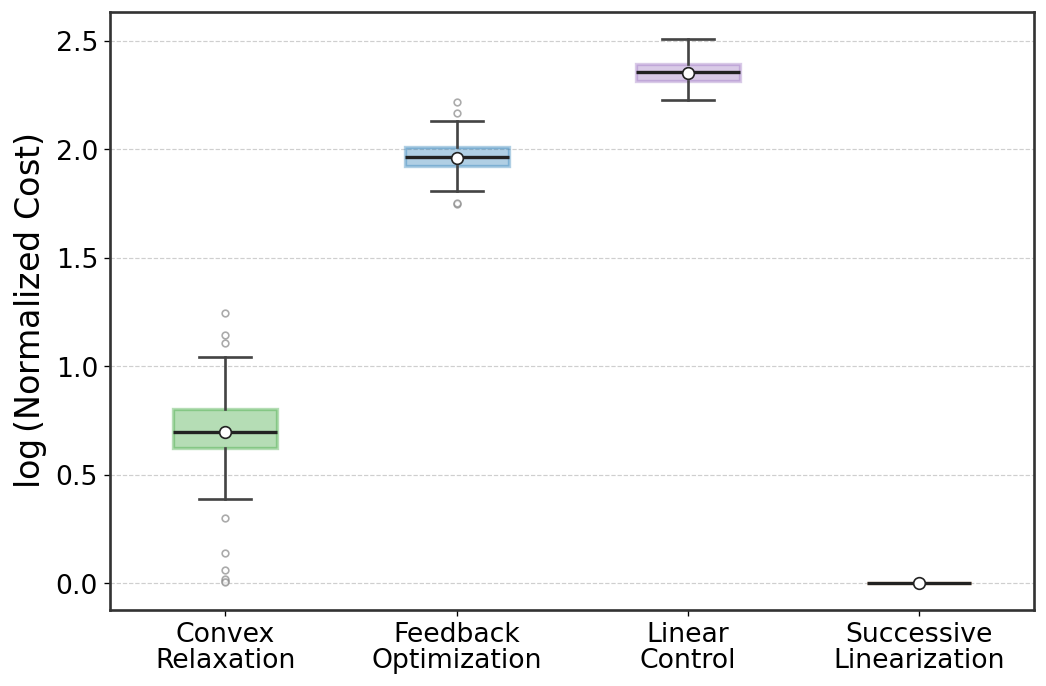


Saved log-normalized boxplot to figures_static/cvc_gd_lin_sc_box_lognorm_tail5.pdf


In [23]:
plot_order = ["cvc", "gd", "lin", "sc"]
methods    = ["lin", "gd", "sc", "cvc"]

xtick_labels_multiline = [
    "Convex\nRelaxation",
    "Feedback\nOptimization",
    "Linear\nControl",
    "Successive\nLinearization",
]

legend_labels = [
    "Convex Relaxation",
    "Feedback Optimization",
    "Linear Control",
    "Successive Linearization",
]

colors = [
    "#2ca02c",
    "#1f77b4",
    "#9467bd",
    "#ff7f0e",
]

name_map = {
    "lin": "Linear Control",
    "gd":  "Feedback Optimization",
    "sc":  "Successive Linearization",
    "cvc": "Convex Relaxation",
}

def _collect_lognorm_metric(metric_suffix: str,
                             eps: float = 1e-12):

    per_seed = ALL_RESULTS.get("per_seed", [])
    log_vals_by_method = {m: [] for m in methods}

    for i, seed_pack in enumerate(per_seed):
        sid = int(seed_pack.get("seed_index", i))

        vals_by_method = {}
        for m in methods:
            key = f"{m}_{metric_suffix}"
            vals_by_method[m] = float(seed_pack.get(key, float("nan")))

        finite_vals = [v for v in vals_by_method.values() if np.isfinite(v)]
        if not finite_vals:
            print(f"Seed {sid:02d}: all NaN for {metric_suffix}, skip.")
            continue

        baseline = min(finite_vals)
        for m in methods:
            v = vals_by_method[m]
            if not np.isfinite(v):
                log_v = float("nan")
            else:
                log_v = np.log10((v + eps) / (baseline + eps))
            log_vals_by_method[m].append(log_v)

    for m in methods:
        log_vals_by_method[m] = np.asarray(log_vals_by_method[m], float)

    return log_vals_by_method


def plot_box_for_lognorm_metric(metric_suffix: str,
                                filename_suffix: str):
    log_vals_by_method = _collect_lognorm_metric(metric_suffix)

    data = [log_vals_by_method[m] for m in plot_order]


    for m in plot_order:
        vals = log_vals_by_method[m]

    fig, ax = plt.subplots(figsize=(9, 6), dpi=120)
    bplot = ax.boxplot(
        data,
        labels=xtick_labels_multiline,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(
            marker='o',
            markersize=7,
            markerfacecolor='white',
            markeredgecolor='#222',
            linewidth=1.4
        ),
        medianprops=dict(color='#222', linewidth=2.0),
        whiskerprops=dict(color='#444', linewidth=1.6),
        capprops=dict(color='#444', linewidth=1.6),
        flierprops=dict(
            marker='o',
            markersize=4,
            markerfacecolor='white',
            markeredgecolor='#888',
            alpha=0.7
        )
    )

    for patch, c in zip(bplot['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.35)
        patch.set_edgecolor(c)
        patch.set_linewidth(2.0)

    ax.set_ylabel(r"$\log$(Normalized Cost)", fontsize=20)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.tick_params(axis='both', labelsize=16)

    plt.setp(ax.get_xticklabels(), ha='center', linespacing=1.0, fontsize=16)
    plt.subplots_adjust(bottom=0.25)

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#333")
        ax.spines[side].set_linewidth(1.6)
    plt.tight_layout()
    os.makedirs(out_dir, exist_ok=True)
    out_pdf = os.path.join(out_dir, filename_suffix)
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    print(f"\nSaved log-normalized boxplot to {out_pdf}")


plot_box_for_lognorm_metric(
    metric_suffix="tail5_mean",
    filename_suffix="cvc_gd_lin_sc_box_lognorm_tail5.pdf"
)
